# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of two diffusion-based synthetic data generation models:
1. **TabDDPM** - Conditional Tabular GAN plus
2. **ForestDiffusion** - Forest-based diffusion for tabular data 

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# Generating synthetic data

In [1]:
# Diffusion model dependencies
# TabDDPM: yandex-research/tab-ddpm (_vendor/tab-ddpm)
# ForestDiffusion: pip install ForestDiffusion
# libzero/rtdl pin torch<2; use --no-deps on torch 2.x (TabDDPM still works)
%pip install -q ForestDiffusion xgboost category-encoders imbalanced-learn absl-py tensorboardX icecream dython optuna skorch pyarrow tomli tomli-w
%pip install -q "pynvml>=11,<12"
%pip install -q "libzero==0.0.8" "rtdl==0.0.13" --no-deps

import sys
from pathlib import Path

NOTEBOOK_DIR = Path(".").resolve()
REPO_ROOT = next(
    (p for p in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
     if (p / "_vendor" / "tab-ddpm").is_dir()),
    NOTEBOOK_DIR.parents[1],
)
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm"))
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm" / "scripts"))
sys.path.insert(0, str(NOTEBOOK_DIR))

# Verify vendored TabDDPM checkouts (see README Setup)
_vendor_missing = [
    p.name for p in [
        REPO_ROOT / "_vendor" / "tab-ddpm",
    ]
    if not p.exists()
]
if _vendor_missing:
    raise FileNotFoundError(
        "Missing _vendor checkouts: "
        + ", ".join(_vendor_missing)
        + ". Clone per README: git clone https://github.com/yandex-research/tab-ddpm _vendor/tab-ddpm"
    )

from diffusion_generators import (
    MODEL_ORDER,
    train_tabddpm,
    train_forestdiffusion,
)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# -----------------------------
# Load Adult dataset
# -----------------------------
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets
data = pd.concat([X, y], axis=1)

target_col = "income"

# Replace ? with NaN
data = data.replace("?", np.nan)

# Binary income target: <=50K vs >50K (strip trailing dots from UCI labels)
data[target_col] = (
    data[target_col].astype(str).str.replace(".", "", regex=False).str.strip()
)
data = data[data[target_col].isin(["<=50K", ">50K"])].reset_index(drop=True)
print("Income classes:", sorted(data[target_col].unique()))
print(data[target_col].value_counts())

# Fill missing feature values before training
for col in data.select_dtypes(include=[np.number]).columns:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mean())
for col in data.select_dtypes(include=["object"]).columns:
    if col != target_col and data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode().iloc[0])

# Feature types: all columns used by generators (cat -> LabelEncoder inside diffusion_generators)
feature_cat_cols = [
    c for c in data.columns
    if c != target_col and str(data[c].dtype) in ("object", "category", "string")
]
feature_num_cols = [c for c in data.columns if c not in feature_cat_cols and c != target_col]
_categorical_columns = feature_cat_cols + [target_col]
print(f"Numeric features ({len(feature_num_cols)}): {feature_num_cols}")
print(f"Categorical features ({len(feature_cat_cols)}): {feature_cat_cols}")

# -----------------------------
# Stratified subsample + leak-safe split (preserves <=50K / >50K ratio)
# -----------------------------
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

_bench_n = min(1000, len(data))
_sss = StratifiedShuffleSplit(n_splits=1, train_size=_bench_n, random_state=42)
_sub_idx, _ = next(_sss.split(data, data[target_col]))
data = data.iloc[_sub_idx].reset_index(drop=True)
print(f"\nStratified subsample (n={len(data)}):")
print(data[target_col].value_counts())

train_real, test_real = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data[target_col],
)
print(f"Train: {train_real[target_col].value_counts().to_dict()}")
print(f"Test:  {test_real[target_col].value_counts().to_dict()}")
# -----------------------------
# Diffusion models (TabDDPM, ForestDiffusion)
# -----------------------------
SYNTHETIC_N = 1000
DIFFUSION_SEED = 42
print("Training TabDDPM...")
synthetic_tabddpm = train_tabddpm(
    train_real,
    target_col=target_col,
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)
print("Training ForestDiffusion...")
synthetic_forestdiffusion = train_forestdiffusion(
    train_real,
    target_col=target_col,
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)

synthetic_outputs = {
    "TabDDPM": synthetic_tabddpm,
    "ForestDiffusion": synthetic_forestdiffusion,
}
model_order = ["TabDDPM", "ForestDiffusion"]

# Alias used by downstream fidelity / utility evaluation cells
real_sample = data.copy()


Income classes: ['<=50K', '>50K']
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
Numeric features (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Stratified subsample (n=1000):
income
<=50K    761
>50K     239
Name: count, dtype: int64
Train: {'<=50K': 609, '>50K': 191}
Test:  {'<=50K': 152, '>50K': 48}
Training TabDDPM...
[0]
87
{'num_classes': 2, 'is_y_cond': False, 'rtdl_params': {'d_layers': [256, 256, 256], 'dropout': 0.0}, 'd_in': np.int64(87)}
mlp
Step 500/1000 MLoss: 0.0 GLoss: 0.2984 Sum: 0.2984
Step 1000/1000 MLoss: 0.0 GLoss: 0.2512 Sum: 0.2512
mlp
Sample timestep    0
Discrete cols: [2, 3, 4]
Num shape:  (1000, 6)
Training ForestDiffusion...


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 369.91it/s]|
Column Shapes Score: 39.53%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 116.07it/s]|
Column Pair Trends Score: 10.92%

Overall Score (Average): 25.22%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 616.51it/s]|
Column Shapes Score: 83.29%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 133.11it/s]|
Column Pair Trends Score: 75.8%

Overall Score (Average): 79.54%



,Model,Average_Column_Shapes_Score
1,ForestDiffusion,0.832867
0,TabDDPM,0.395267


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1539295201.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1539295201.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


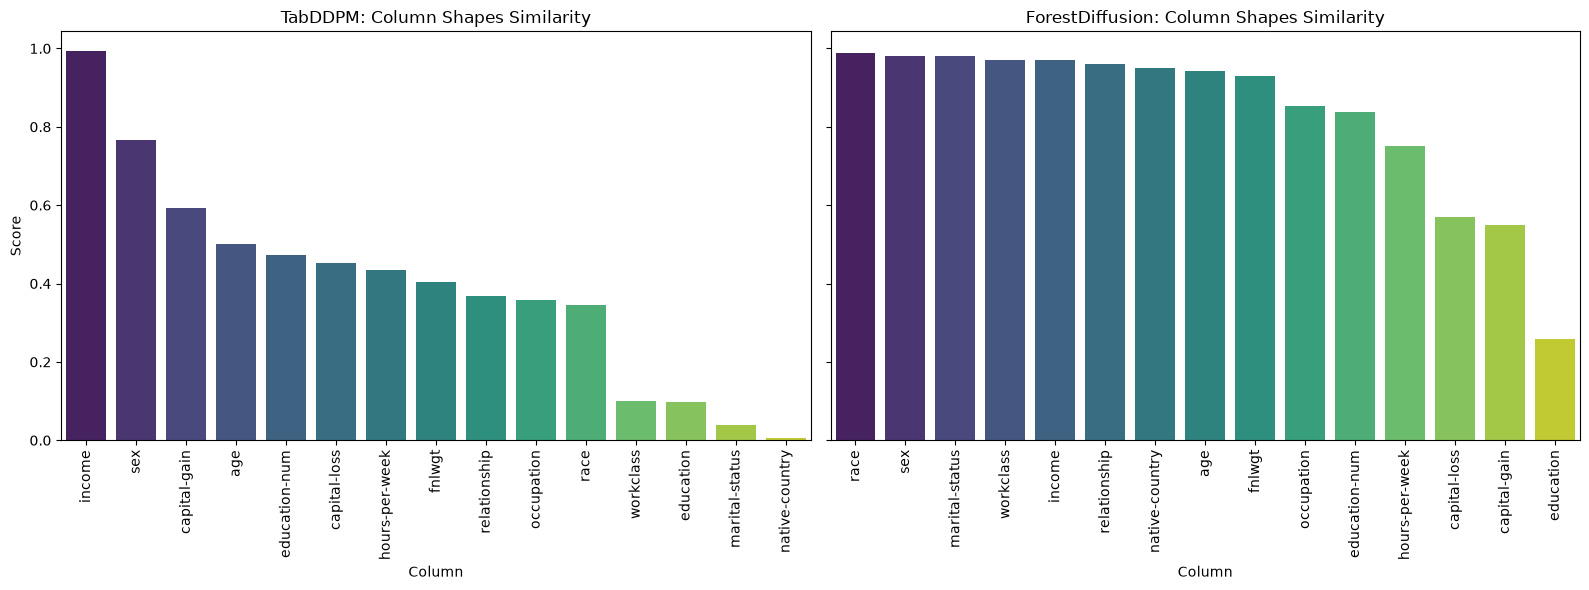

,Column,Metric,Score,Model
0,income,TVComplement,0.994,TabDDPM
1,sex,TVComplement,0.766,TabDDPM
2,capital-gain,KSComplement,0.593,TabDDPM
3,age,KSComplement,0.500,TabDDPM
4,education-num,KSComplement,0.472,TabDDPM
5,capital-loss,KSComplement,0.452,TabDDPM
6,hours-per-week,KSComplement,0.434,TabDDPM
7,fnlwgt,KSComplement,0.403,TabDDPM
8,relationship,TVComplement,0.368,TabDDPM
9,occupation,TVComplement,0.358,TabDDPM


In [3]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sdv.metadata import SingleTableMetadata

# -----------------------------
# 1. Use cleaned real data
# -----------------------------
# real_data should be the same 1000-row cleaned dataset used earlier
# For example:
# real_data = data.copy()

real_data = data.copy()

# Keep only columns that exist in both real and synthetic outputs if needed
# real_data = real_data[synthetic_outputs["TabDDPM"].columns.intersection(real_data.columns)]

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)

model_order = ["TabDDPM", "ForestDiffusion"]
column_shape_details = {}
summary_rows = []

for model_name in model_order:
    qr = QualityReport()
    synthetic_data = synthetic_outputs[model_name]

    # Align columns to avoid mismatch errors
    common_cols = real_data.columns.intersection(synthetic_data.columns)
    real_eval = real_data[common_cols].copy()
    synth_eval = synthetic_data[common_cols].copy()

    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata.to_dict()
    )

    details = qr.get_details("Column Shapes")

    # Handle either "Score" or "Quality Score" depending on SDV version
    score_col = "Score" if "Score" in details.columns else "Quality Score"
    details = details.sort_values(score_col, ascending=False)
    column_shape_details[model_name] = details

    summary_rows.append({
        "Model": model_name,
        "Average_Column_Shapes_Score": float(details[score_col].mean())
    })

# -----------------------------
# 2. Summary table
# -----------------------------
summary_df = pd.DataFrame(summary_rows).sort_values(
    "Average_Column_Shapes_Score", ascending=False
)
display(summary_df)

# -----------------------------
# 3. Plot column-shape scores
# -----------------------------
fig, axes = plt.subplots(1, len(model_order), figsize=(16, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    score_col = "Score" if "Score" in details.columns else "Quality Score"

    sns.barplot(
        x="Column",
        y=score_col,
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# -----------------------------
# 4. Combined details table
# -----------------------------
combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


### 1.2. Jensen–Shannon divergence

In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

Computing JS divergence for TabDDPM...
Computing JS divergence for ForestDiffusion...


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\566935569.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\566935569.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


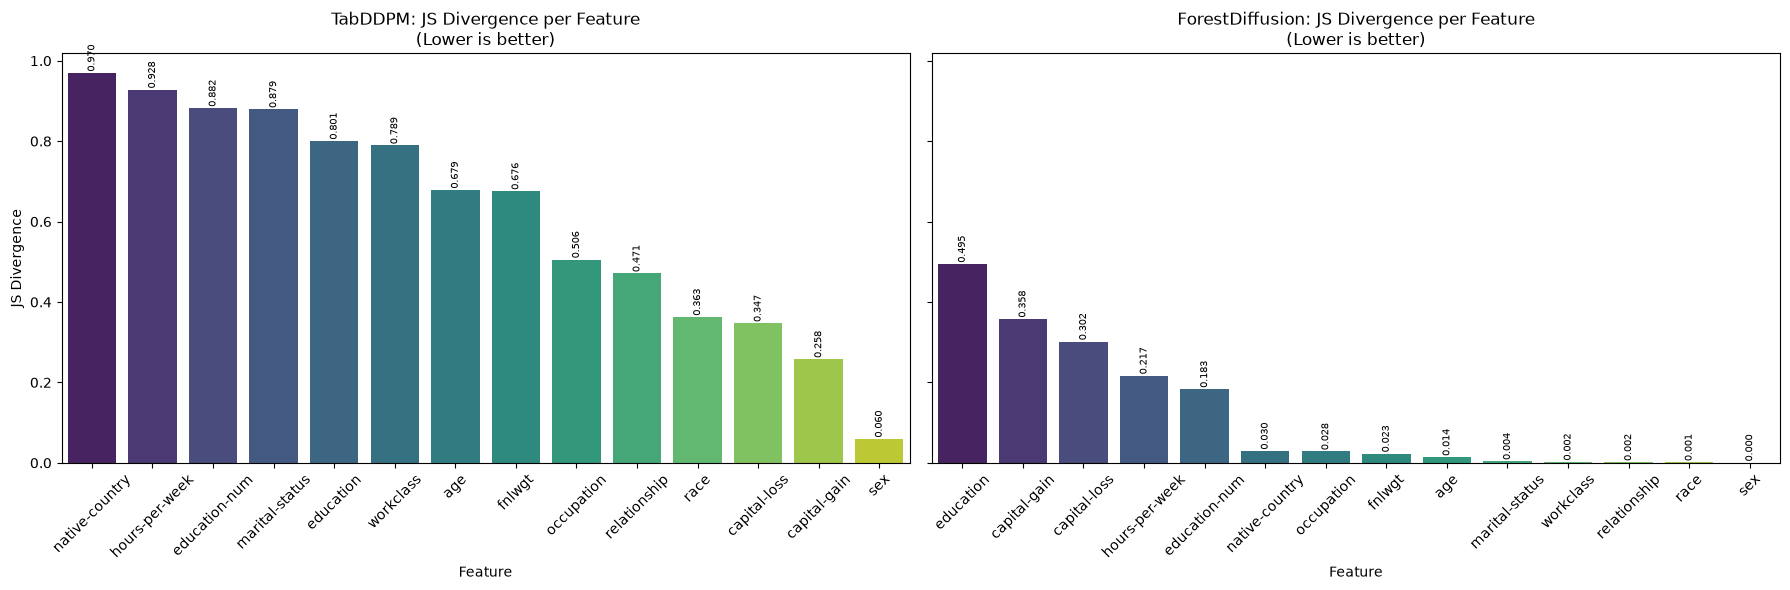

Top 20 features by JS Divergence:


,Feature,JS_Divergence,Model
0,native-country,0.969914,TabDDPM
1,hours-per-week,0.927843,TabDDPM
2,education-num,0.882366,TabDDPM
3,marital-status,0.879256,TabDDPM
4,education,0.800590,TabDDPM
5,workclass,0.789259,TabDDPM
6,age,0.678863,TabDDPM
7,fnlwgt,0.675851,TabDDPM
8,occupation,0.505532,TabDDPM
9,relationship,0.471145,TabDDPM



Model Comparison Summary (Lower JS = Better):


,Model,Mean_JS,Median_JS,Max_JS,Features_with_JS_gt_0.1
1,ForestDiffusion,0.118464,0.025538,0.494560,5
0,TabDDPM,0.614837,0.677357,0.969914,13


In [5]:
# Use the real_sample from previous cell (1000 rows)
real_df = real_sample.drop(columns=[target_col])  

model_order = ["TabDDPM", "ForestDiffusion"]
js_results_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    
    print(f"Computing JS divergence for {model_name}...")
    js_df = compute_js_divergence(
        real_df,
        synth_df,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    
    js_results_by_model[model_name] = js_df

# -----------------------------
# Plot JS Divergence
# -----------------------------
fig, axes = plt.subplots(1, len(model_order), figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df.head(15),  # Top 15 features for cleaner plot
        palette="viridis",
        ax=ax
    )

    # Add value labels on bars
    for bar in bars.patches:
        yval = bar.get_height()
        if not np.isnan(yval):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval + 0.003,
                f"{yval:.3f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90
            )

    ax.set_title(f"{model_name}: JS Divergence per Feature\n(Lower is better)", fontsize=12)
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# -----------------------------
# Summary table
# -----------------------------
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)

print("Top 20 features by JS Divergence:")
display(all_js.head(20))

# -----------------------------
# Model comparison summary
# -----------------------------
summary_stats = []
for model_name, js_df in js_results_by_model.items():
    valid_js = js_df["JS_Divergence"].dropna()
    summary_stats.append({
        "Model": model_name,
        "Mean_JS": valid_js.mean(),
        "Median_JS": valid_js.median(),
        "Max_JS": valid_js.max(),
        "Features_with_JS_gt_0.1": (valid_js > 0.1).sum()
    })

summary_df = pd.DataFrame(summary_stats).sort_values("Mean_JS")
print("\nModel Comparison Summary (Lower JS = Better):")
display(summary_df)


### 1.3 Wasserstein Distance


Numeric columns (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss']...
Categorical columns (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship']...

Using 6 numeric features for Wasserstein distance

Computing Wasserstein distances...

TabDDPM - Wasserstein Distance (numeric features only):
  age            : 0.3344
  fnlwgt         : 0.4500
  education-num  : 0.3415
  capital-gain   : 0.4000
  capital-loss   : 0.2787
  hours-per-week : 0.4118
ForestDiffusion - Wasserstein Distance (numeric features only):
  age            : 0.0219
  fnlwgt         : 0.0219
  education-num  : 0.0149
  capital-gain   : 0.0055
  capital-loss   : 0.0093
  hours-per-week : 0.0241

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein,Num_Valid_Features
0,ForestDiffusion,0.016267,0.018395,0.024117,6
1,TabDDPM,0.369429,0.370784,0.450029,6


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1215645217.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1215645217.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


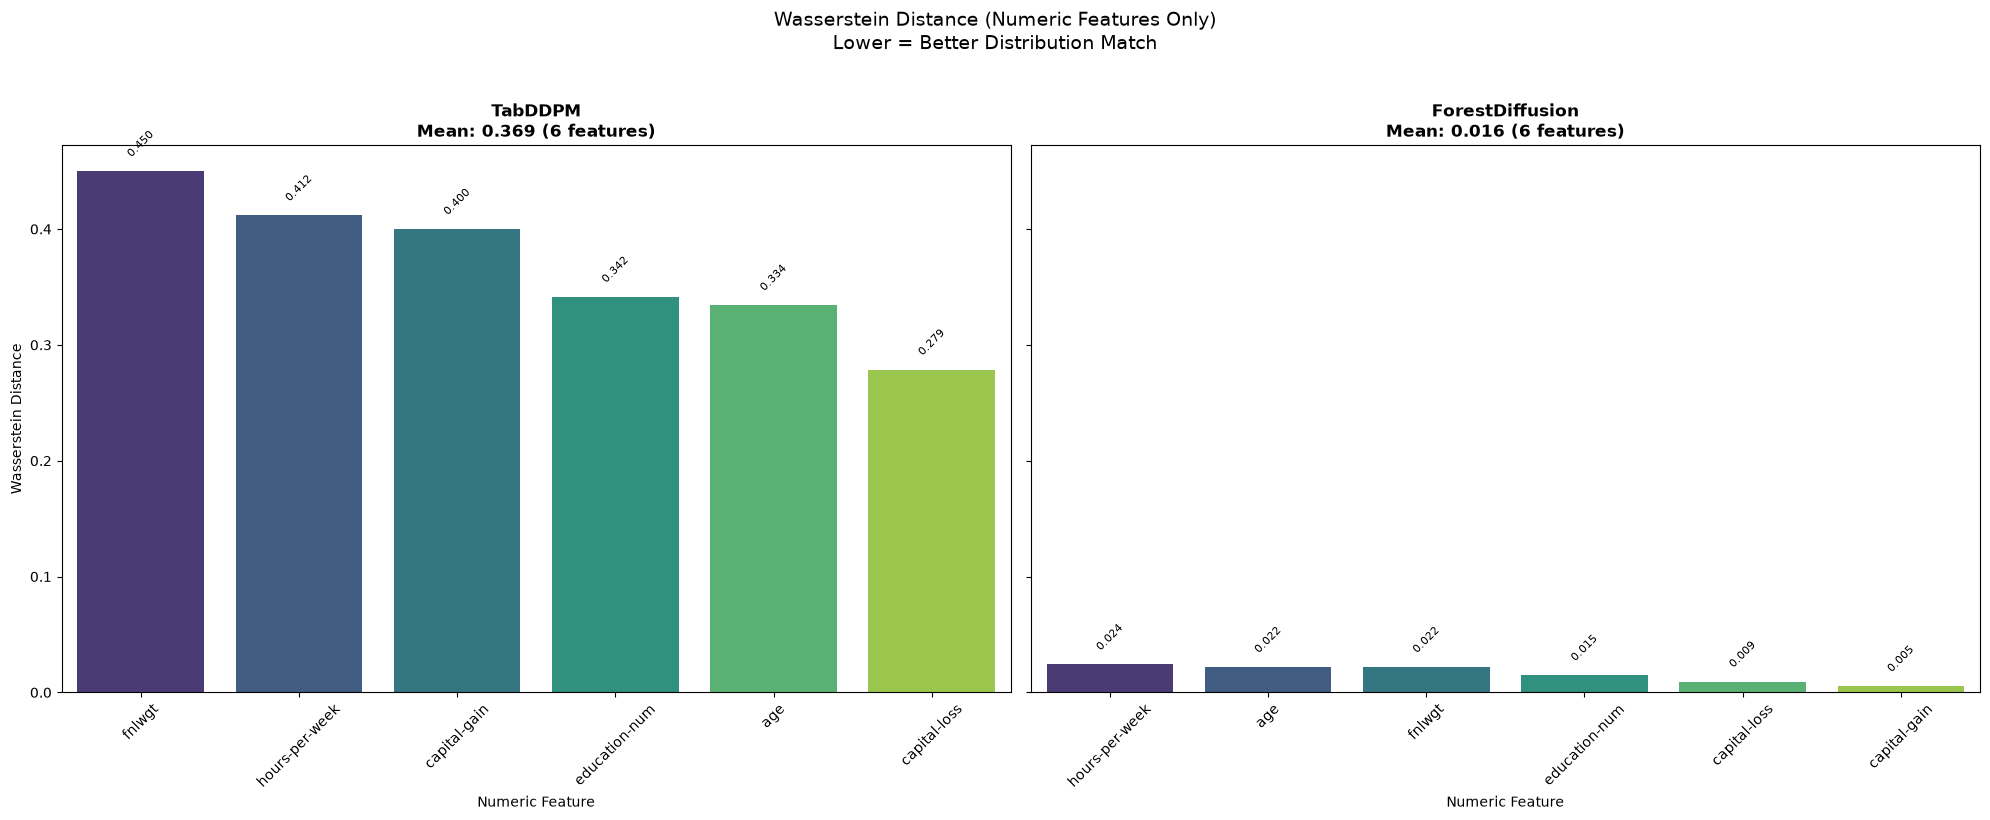


Top 20 numeric features by Wasserstein Distance:


,Feature,Wasserstein_Distance,Model
0,fnlwgt,0.450029,TabDDPM
1,hours-per-week,0.411806,TabDDPM
2,capital-gain,0.400034,TabDDPM
3,education-num,0.341533,TabDDPM
4,age,0.334438,TabDDPM
5,capital-loss,0.278732,TabDDPM
6,hours-per-week,0.024117,ForestDiffusion
7,age,0.021898,ForestDiffusion
8,fnlwgt,0.021895,ForestDiffusion
9,education-num,0.014895,ForestDiffusion


In [6]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

# Use real_sample and target_col from previous generation cell
real_df = real_sample.drop(columns=[target_col])

# -----------------------------
# SEPARATE NUMERIC AND CATEGORICAL COLUMNS
# -----------------------------
numeric_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = real_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:5]}...")

# Only use NUMERIC columns for Wasserstein (skip categorical)
real_numeric = real_df[numeric_cols].copy()
print(f"\nUsing {len(numeric_cols)} numeric features for Wasserstein distance")

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_numeric),
    columns=numeric_cols,
    index=real_numeric.index
)

wasserstein_by_model = {}
summary_rows = []

print("\nComputing Wasserstein distances...\n")

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    synth_numeric = synth_df[numeric_cols].copy()
    
    # Clean numeric data (handle inf/NaN)
    synth_numeric = synth_numeric.replace([np.inf, -np.inf], np.nan)
    synth_numeric = synth_numeric.fillna(synth_numeric.median())
    
    # Scale synthetic data using real data's scaler
    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols,
        index=synth_numeric.index
    )
    
    dists = []
    print(f"{model_name} - Wasserstein Distance (numeric features only):")
    
    for col in numeric_cols:
        try:
            real_col = real_scaled[col].dropna()
            synth_col = synthetic_scaled[col].dropna()
            
            if len(real_col) > 1 and len(synth_col) > 1:
                dist = wasserstein_distance(real_col, synth_col)
                dists.append((col, float(dist)))
                print(f"  {col:15}: {dist:.4f}")
            else:
                dists.append((col, np.nan))
                print(f"  {col:15}: NaN (insufficient data)")
        except Exception as e:
            dists.append((col, np.nan))
            print(f"  {col:15}: NaN (error: {str(e)[:30]})")
    
    # FIXED: Remove na_last parameter for older pandas
    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)
    
    wasserstein_by_model[model_name] = dist_df
    
    valid_dists = dist_df["Wasserstein_Distance"].dropna()
    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": valid_dists.mean() if len(valid_dists) > 0 else np.nan,
        "Median_Wasserstein": valid_dists.median() if len(valid_dists) > 0 else np.nan,
        "Max_Wasserstein": valid_dists.max() if len(valid_dists) > 0 else np.nan,
        "Num_Valid_Features": len(valid_dists)
    })

# FIXED: Remove na_last parameter
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot TOP 15 numeric features only
fig, axes = plt.subplots(1, len(model_order), figsize=(20, 8), sharey=True)

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name].dropna().head(15)
    
    if len(df_plot) > 0:
        bars = sns.barplot(
            x="Feature",
            y="Wasserstein_Distance",
            data=df_plot,
            palette="viridis",
            ax=ax
        )
        
        # Add value labels
        for bar in bars.patches:
            yval = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval + 0.01,
                f"{yval:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=45
            )
        
        mean_ws = summary_df[summary_df['Model']==model_name]['Mean_Wasserstein'].iloc[0]
        ax.set_title(f"{model_name}\nMean: {mean_ws:.3f} ({len(df_plot)} features)", 
                    fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No numeric data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(model_name)
    
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Numeric Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.suptitle("Wasserstein Distance (Numeric Features Only)\nLower = Better Distribution Match", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# FIXED: Remove na_last parameter
all_wasserstein = pd.concat(
    [df.assign(Model=name) for name, df in wasserstein_by_model.items()],
    ignore_index=True
).sort_values("Wasserstein_Distance", ascending=False)

print("\nTop 20 numeric features by Wasserstein Distance:")
display(all_wasserstein.head(20))


### 1.4 Gower Distance

In [7]:
import numpy as np
import pandas as pd
import gower

# Use correct variables from Adult dataset pipeline
data = real_sample.copy()
model_order = ["TabDDPM", "ForestDiffusion"]
target_col = data.columns[-1]  # Use last column as target (income)

X_real = data.drop(columns=[target_col], errors="ignore")

gower_results = []

print("Computing Gower distances (mixed data)...\n")

for model_name in model_order:
    X_synth = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    
    # Align columns exactly
    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)
    
    print(f"{model_name}: {len(Xr)} real vs {len(Xs)} synth samples, {len(common_cols)} features")
    
    # Gower similarity matrices (1 - distance)
    try:
        gower_real = 1 - gower.gower_matrix(Xr)
        gower_synth = 1 - gower.gower_matrix(Xs)
        
        # Upper triangle (excluding diagonal)
        real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
        synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]
        
        max_intra_real = np.max(real_upper)
        avg_intra_real = np.mean(real_upper)
        max_intra_synth = np.max(synth_upper)
        avg_intra_synth = np.mean(synth_upper)
        
        # Cross similarity (real vs synthetic)
        combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
        gower_combined = 1 - gower.gower_matrix(combined)
        n_real = len(Xr)
        cross_block = gower_combined[:n_real, n_real:]
        
        max_cross = np.max(cross_block)
        avg_cross = np.mean(cross_block)
        
        print(f"\n{model_name} - Gower Similarity:")
        print("Intra-set Similarity (Real):")
        print(f"  Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}")
        print("Intra-set Similarity (Synthetic):")
        print(f"  Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}")
        print("Cross-set Similarity (Real vs Synthetic):")
        print(f"  Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")
        
        gower_results.append({
            "Model": model_name,
            "Max_Intra_Real": max_intra_real,
            "Avg_Intra_Real": avg_intra_real,
            "Max_Intra_Synth": max_intra_synth,
            "Avg_Intra_Synth": avg_intra_synth,
            "Max_Cross_Real_vs_Synth": max_cross,
            "Avg_Cross_Real_vs_Synth": avg_cross,
        })
        
    except Exception as e:
        print(f"Error computing Gower for {model_name}: {str(e)}")
        continue

# Summary table
if gower_results:
    gower_summary_df = pd.DataFrame(gower_results)
    print("\nGower Similarity Summary:")
    print("(Higher similarity = better; ideal: synth intra ≈ real intra ≈ cross)")
    display(gower_summary_df)
    
    # Add interpretation
    for _, row in gower_summary_df.iterrows():
        model = row['Model']
        real_avg = row['Avg_Intra_Real']
        synth_avg = row['Avg_Intra_Synth']
        cross_avg = row['Avg_Cross_Real_vs_Synth']
        
        print(f"\n{model} interpretation:")
        if abs(synth_avg - real_avg) < 0.05 and abs(cross_avg - real_avg) < 0.05:
            print(" Good: Synthetic matches real data distribution")
        elif synth_avg > real_avg * 1.1:
            print("  Synthetic data is less diverse than real")
        elif cross_avg < real_avg * 0.8:
            print("  Poor: Synthetic doesn't resemble real data")
        else:
            print(" Moderate quality")
else:
    print("No valid Gower results computed")


Computing Gower distances (mixed data)...

TabDDPM: 1000 real vs 1000 synth samples, 14 features

TabDDPM - Gower Similarity:
Intra-set Similarity (Real):
  Max = 1.0000, Avg = 0.6337
Intra-set Similarity (Synthetic):
  Max = 1.0000, Avg = 0.5011
Cross-set Similarity (Real vs Synthetic):
  Max = 0.6870, Avg = 0.3135
ForestDiffusion: 1000 real vs 1000 synth samples, 14 features

ForestDiffusion - Gower Similarity:
Intra-set Similarity (Real):
  Max = 1.0000, Avg = 0.6337
Intra-set Similarity (Synthetic):
  Max = 0.9991, Avg = 0.7021
Cross-set Similarity (Real vs Synthetic):
  Max = 0.9991, Avg = 0.6454

Gower Similarity Summary:
(Higher similarity = better; ideal: synth intra ≈ real intra ≈ cross)


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,TabDDPM,1.0,0.633696,1.000000,0.501060,0.686955,0.313479
1,ForestDiffusion,1.0,0.633696,0.999124,0.702081,0.999094,0.645353



TabDDPM interpretation:
  Poor: Synthetic doesn't resemble real data

ForestDiffusion interpretation:
  Synthetic data is less diverse than real


### 1.5 t-SNE Visualization


Using 6 numeric features for t-SNE: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


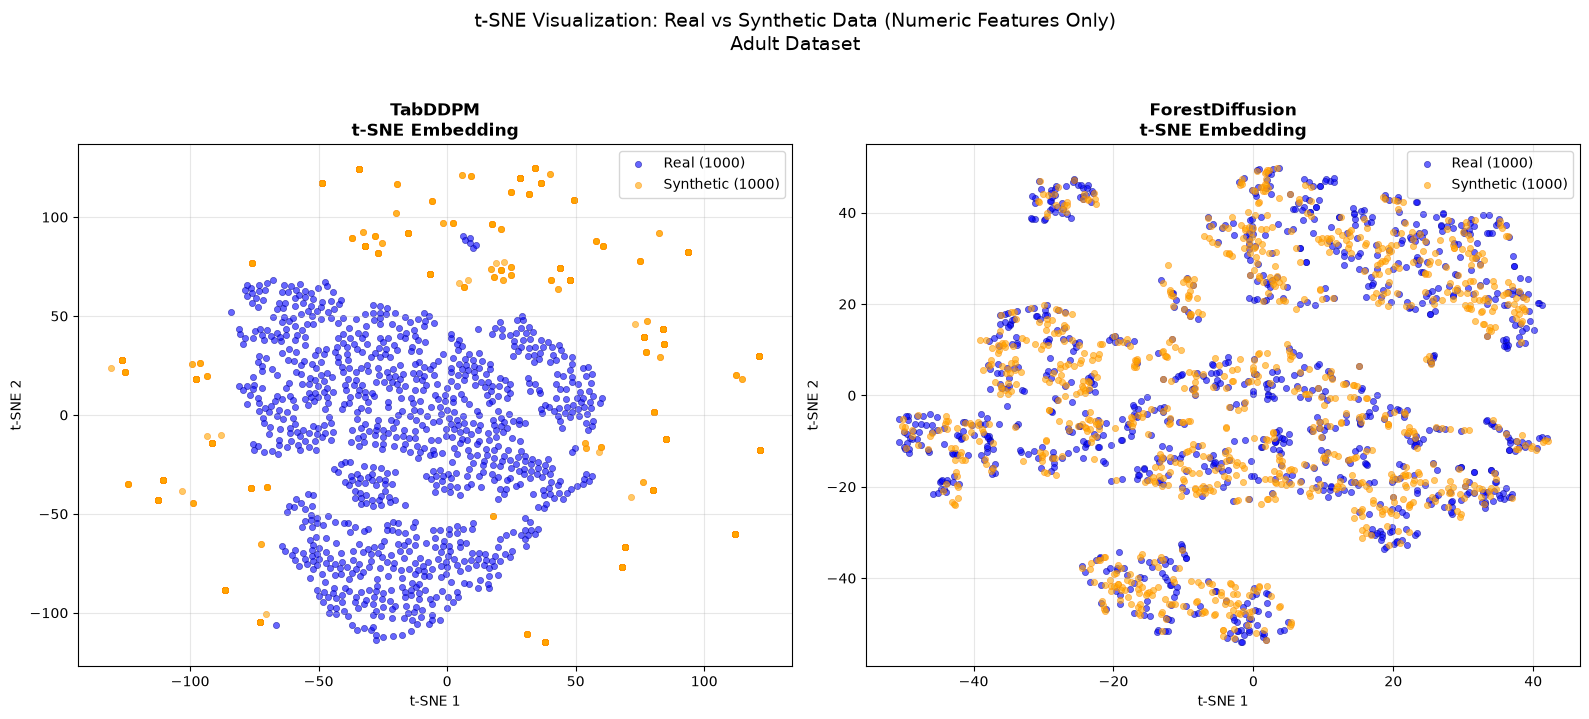


Overlap Analysis:
TabDDPM: Centroid distance = 1.397
Good overlap
ForestDiffusion: Centroid distance = 1.397
Good overlap


In [8]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use correct Adult dataset variables
model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = data.columns[-1]  # income target column

# Remove target and separate numeric/categorical
X_real = data.drop(columns=[target_col], errors="ignore")

# -----------------------------
# USE ONLY NUMERIC COLUMNS (like before)
# -----------------------------
numeric_cols = X_real.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(numeric_cols)} numeric features for t-SNE: {numeric_cols}")

X_real_numeric = X_real[numeric_cols].copy()

# Scale numeric data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(X_real_numeric),
    columns=numeric_cols,
    index=X_real_numeric.index
)

# Create t-SNE plots
fig, axes = plt.subplots(1, len(model_order), figsize=(16, 7))
axes = axes.flatten()

for i, model_name in enumerate(model_order):
    ax = axes[i]
    
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    synth_numeric = synth_df[numeric_cols].copy()
    
    # Clean synthetic numeric data
    synth_numeric = synth_numeric.replace([np.inf, -np.inf], np.nan)
    synth_numeric = synth_numeric.fillna(synth_numeric.median())
    
    # Scale synthetic data using real scaler
    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols,
        index=synth_numeric.index
    )
    
    # Combine real + synthetic
    combined = np.vstack([
        real_scaled.values, 
        synthetic_scaled.values
    ])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(combined)
    
    # Plot
    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=20, label="Real (1000)", 
        edgecolors='darkblue', linewidth=0.5
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=20, label="Synthetic (1000)",
        edgecolors='darkorange', linewidth=0.5
    )
    
    ax.set_title(f"{model_name}\nt-SNE Embedding", fontsize=12, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("t-SNE Visualization: Real vs Synthetic Data (Numeric Features Only)\nAdult Dataset", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print overlap statistics
print("\nOverlap Analysis:")
for model_name in model_order:
    # Simple convex hull overlap check (optional advanced metric)
    real_points = tsne_result[labels == "Real"][:1000]  # First 1000 real points
    synth_points = tsne_result[labels == "Synthetic"][:1000]  # First 1000 synth points
    
    # Distance between centroids
    real_center = np.mean(real_points, axis=0)
    synth_center = np.mean(synth_points, axis=0)
    centroid_dist = np.linalg.norm(real_center - synth_center)
    
    print(f"{model_name}: Centroid distance = {centroid_dist:.3f}")
    if centroid_dist < 5:
        print("Good overlap")
    else:
        print("Limited overlap")


### 1.6 MMD (Maximum Mean Discrepancy)


In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = data.columns[-1]

# Real features (exclude target) - NUMERIC COLUMNS ONLY
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()
    
    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())
    
    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)
    
    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})
    
    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Lower MMD is better
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)


TabDDPM - MMD score: 0.5646
ForestDiffusion - MMD score: 0.0076

MMD comparison (lower is better):


,Model,MMD_Score
0,ForestDiffusion,0.007571
1,TabDDPM,0.564577


### 1.7 Cosine Similarity


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = data.columns[-1]

# Real features (exclude target) - NUMERIC COLUMNS ONLY
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()
    
    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())
    
    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)
    
    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)
    
    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")
    
    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)



TabDDPM - Sample-Level Similarity:
Average cosine similarity: -0.0547
Maximum cosine similarity: 0.9979

ForestDiffusion - Sample-Level Similarity:
Average cosine similarity: 0.0203
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,ForestDiffusion,0.020289,0.999988
1,TabDDPM,-0.054662,0.997911


### 1.8 Nearest Neighbours 


In [11]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = data.columns[-1]

real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()
    
    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())
    
    # Scale using real data statistics
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)
    
    # Nearest-neighbor privacy check: Synthetic -> Real
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)
    
    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)
    
    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")
    
    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)



TabDDPM - Privacy Check:
Average NN Distance (Synthetic -> Real): 5.5596
Minimum NN Distance (Synthetic -> Real): 1.7675
5th Percentile NN Distance: 2.6756

ForestDiffusion - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.3499
Minimum NN Distance (Synthetic -> Real): 0.0115
5th Percentile NN Distance: 0.0558

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,TabDDPM,5.559633,1.767485,2.675590
1,ForestDiffusion,0.349870,0.011494,0.055781


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,787.660693,83.129493,259.866866
1,ForestDiffusion,15.091778,1.366754,21.832922


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1350698757.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1350698757.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1350698757.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Mo

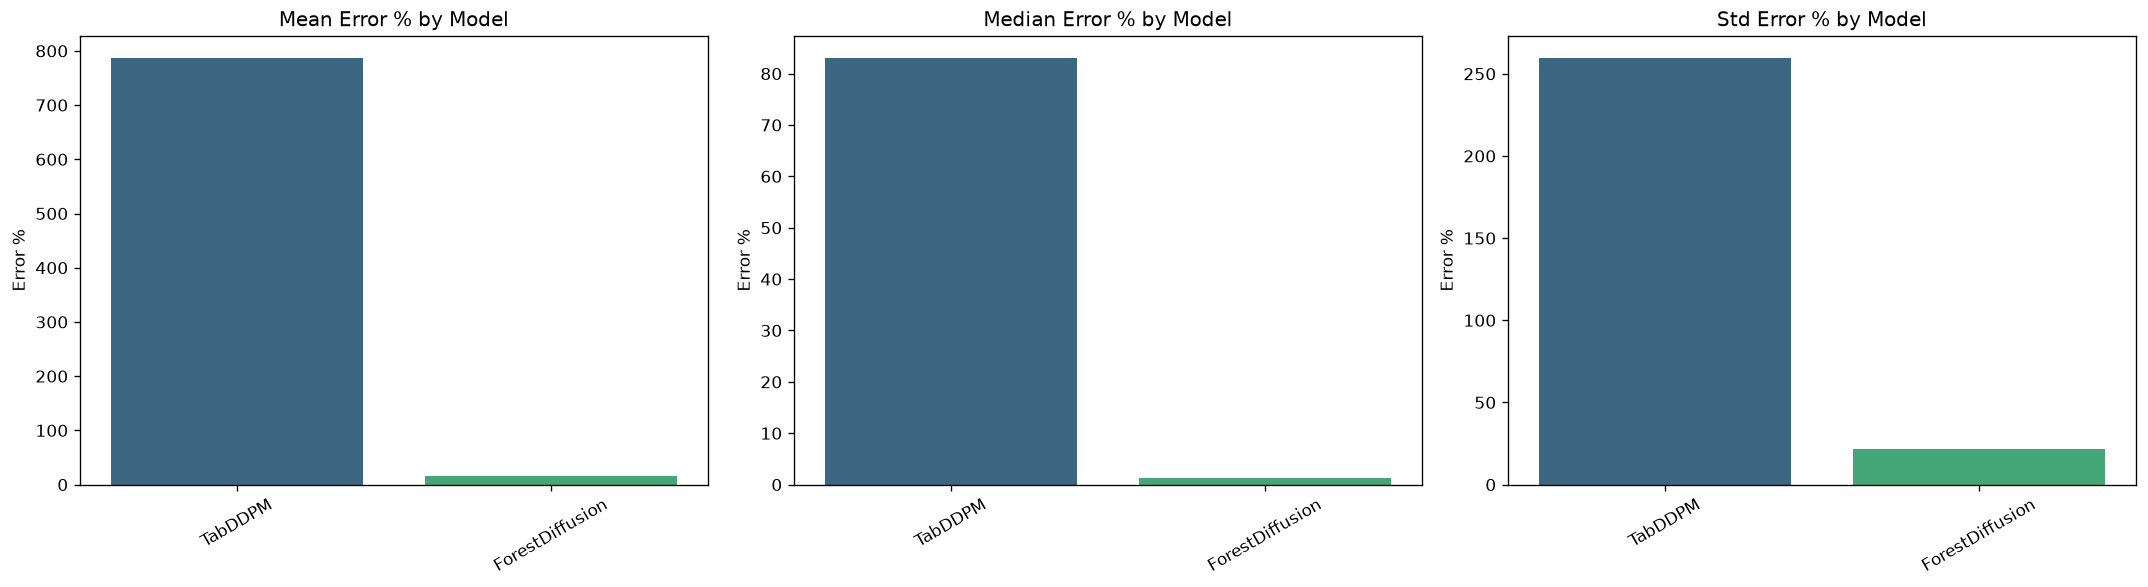

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = data.columns[-1]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_num_cols = synth_df.select_dtypes(include=[np.number]).columns.tolist()
    synth_df = synth_df[num_cols].copy()
    
    # Fill NaN values for numeric computation
    synth_df = synth_df.fillna(synth_df.median())
    
    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()
    
    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)
    
    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100
    
    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)
    
    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }
    
    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1320158940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")


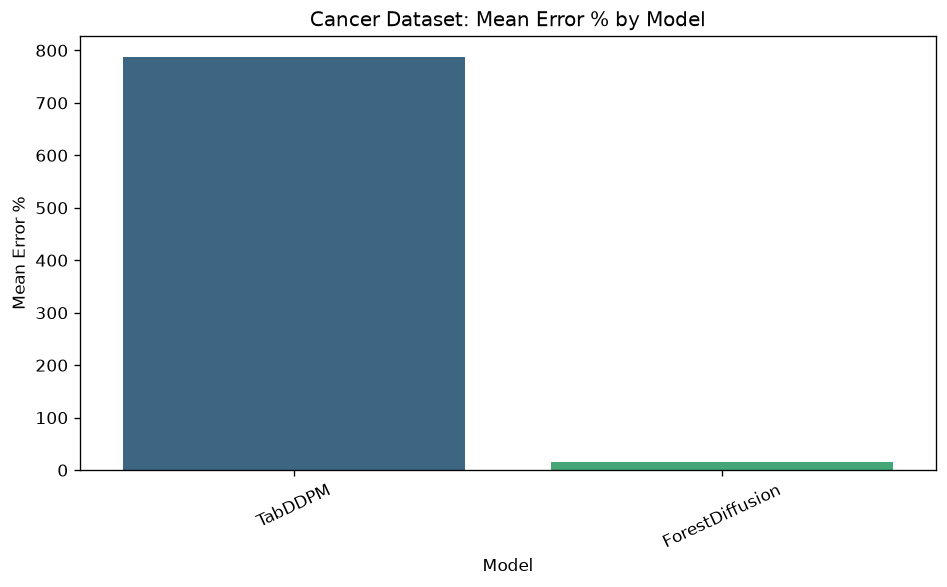

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Cancer Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\243136813.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")


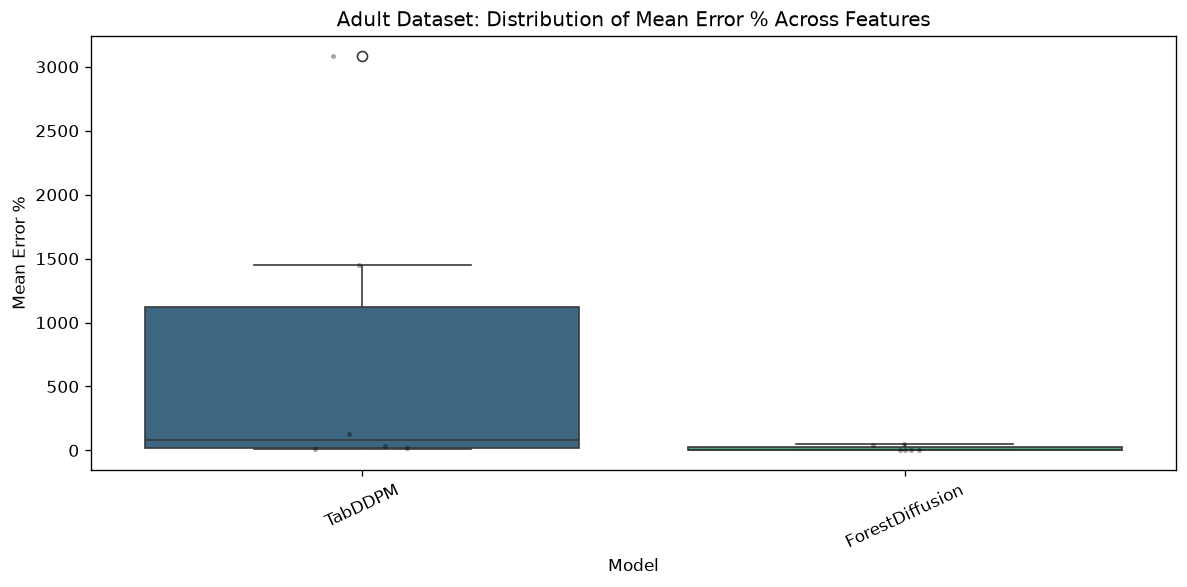

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["TabDDPM", "ForestDiffusion"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_list
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Adult Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


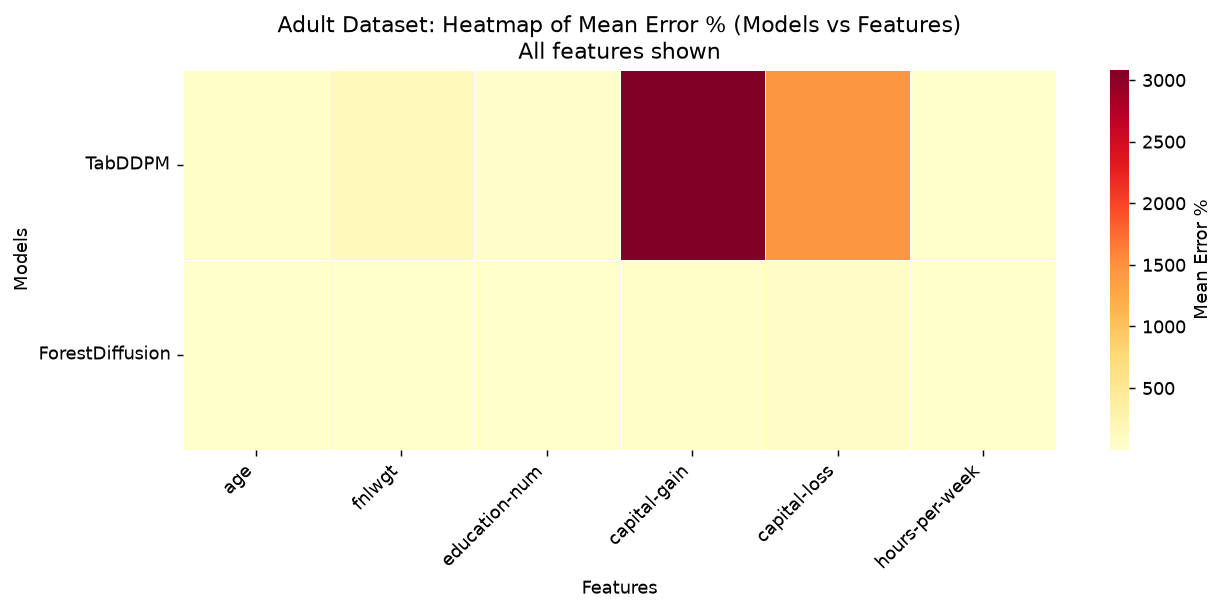

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Adult Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 2 Bivariate Analysis


In [16]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality(real_df, synth_df, target=None):
    """Compute bivariate quality metrics for Adult dataset."""

    if target is None:
        for cand in ["income", "Income", "class", "Class", "target", "Target"]:
            if cand in real_df.columns:
                target = cand
                break

    if target is None or target not in real_df.columns or target not in synth_df.columns:
        raise KeyError("Target column not found in both real_df and synth_df.")

    num_cols = [
        c for c in real_df.columns
        if c != target and pd.api.types.is_numeric_dtype(real_df[c]) and pd.api.types.is_numeric_dtype(synth_df[c])
    ]

    scaler = MinMaxScaler()
    real_scaled = real_df[num_cols].copy()
    synth_scaled = synth_df[num_cols].copy()
    
    # Handle NaN values
    real_scaled = real_scaled.fillna(real_scaled.median())
    synth_scaled = synth_scaled.fillna(synth_scaled.median())

    real_scaled = pd.DataFrame(scaler.fit_transform(real_scaled), columns=num_cols, index=real_scaled.index)
    synth_scaled = pd.DataFrame(scaler.transform(synth_scaled), columns=num_cols, index=synth_scaled.index)

    results_corr = []
    results_target = []

    # Pairwise correlations
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    # Target-conditional distributions
    for col in num_cols:
        try:
            r_groups = [g for _, g in real_df.groupby(target) if len(g) > 0]
            s_groups = [g[col].values for _, g in synth_df.groupby(target) if len(g) > 0]
            
            if len(r_groups) >= 2 and len(s_groups) >= 2:
                # Use first two groups if more than 2
                r_group1 = r_groups[0][col].values
                r_group2 = r_groups[1][col].values
                s_group1 = s_groups[0]
                s_group2 = s_groups[1]
                
                d_real = stats.wasserstein_distance(r_group1, r_group2)
                d_synth = stats.wasserstein_distance(s_group1, s_group2)
                results_target.append({
                    "feature": col,
                    "delta_wasserstein": abs(d_real - d_synth)
                })
        except:
            continue

    corr_df = pd.DataFrame(results_corr)
    if not corr_df.empty:
        corr_df = corr_df.sort_values("delta_corr", ascending=False)
    else:
        corr_df = pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])

    target_df = pd.DataFrame(results_target)
    if not target_df.empty:
        target_df = target_df.sort_values("delta_wasserstein", ascending=False)
    else:
        target_df = pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df

In [17]:
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = data.columns[-1]  # Absolute target column from previous cells

real_df = data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # keep target column if it exists, but align numeric features separately inside the function
    if target_col not in synth_df.columns:
        print(f"Warning: {target_col} not found in synthetic data for {model_name}")
        continue

    corr_df, target_df = bivariate_quality(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_df
    all_target_results[model_name] = target_df

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_df.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by target class:")
    display(target_df.head(10) if not target_df.empty else pd.DataFrame({"message": ["No target-conditional features found"]}))
    print("=" * 60)

    # Safe metric extraction with empty DataFrame handling
    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_df.columns), None)
    target_metric_col = next((c for c in ["delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_df.columns), None)

    top_corr_diff = corr_df[corr_metric_col].iloc[0] if corr_metric_col and not corr_df.empty else None
    mean_top10_corr_diff = corr_df[corr_metric_col].head(10).mean() if corr_metric_col and not corr_df.empty else None
    
    top_target_diff = target_df[target_metric_col].iloc[0] if target_metric_col and not target_df.empty else None
    mean_top10_target_diff = target_df[target_metric_col].head(10).mean() if target_metric_col and not target_df.empty else None

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": top_corr_diff,
        "MeanTop10CorrDiff": mean_top10_corr_diff,
        "TopTargetDiff": top_target_diff,
        "MeanTop10TargetDiff": mean_top10_target_diff,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



TabDDPM - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
8,fnlwgt,hours-per-week,0.783440
4,age,hours-per-week,0.548574
0,age,fnlwgt,0.528455
11,education-num,hours-per-week,0.340273
14,capital-loss,hours-per-week,0.295224
10,education-num,capital-loss,0.286463
5,fnlwgt,education-num,0.273681
9,education-num,capital-gain,0.258369
7,fnlwgt,capital-loss,0.246836
2,age,capital-gain,0.174636


TabDDPM - Features that differ most by target class:


,feature,delta_wasserstein
1,fnlwgt,31176.426821
4,capital-loss,97.454894
3,capital-gain,37.957504
0,age,5.654969
5,hours-per-week,3.159289
2,education-num,1.640510



ForestDiffusion - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
9,education-num,capital-gain,0.110073
5,fnlwgt,education-num,0.062162
4,age,hours-per-week,0.053729
7,fnlwgt,capital-loss,0.045397
2,age,capital-gain,0.035243
12,capital-gain,capital-loss,0.033351
8,fnlwgt,hours-per-week,0.031846
11,education-num,hours-per-week,0.030922
3,age,capital-loss,0.026848
0,age,fnlwgt,0.016790


ForestDiffusion - Features that differ most by target class:


,feature,delta_wasserstein
1,fnlwgt,3674.299230
3,capital-gain,1652.876622
4,capital-loss,43.476515
5,hours-per-week,1.979981
0,age,1.361277
2,education-num,1.286752


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,TabDDPM,0.783440,0.373595,31176.426821,5220.382331
1,ForestDiffusion,0.110073,0.044636,3674.299230,895.880063


### 3 Multivariate Analysis


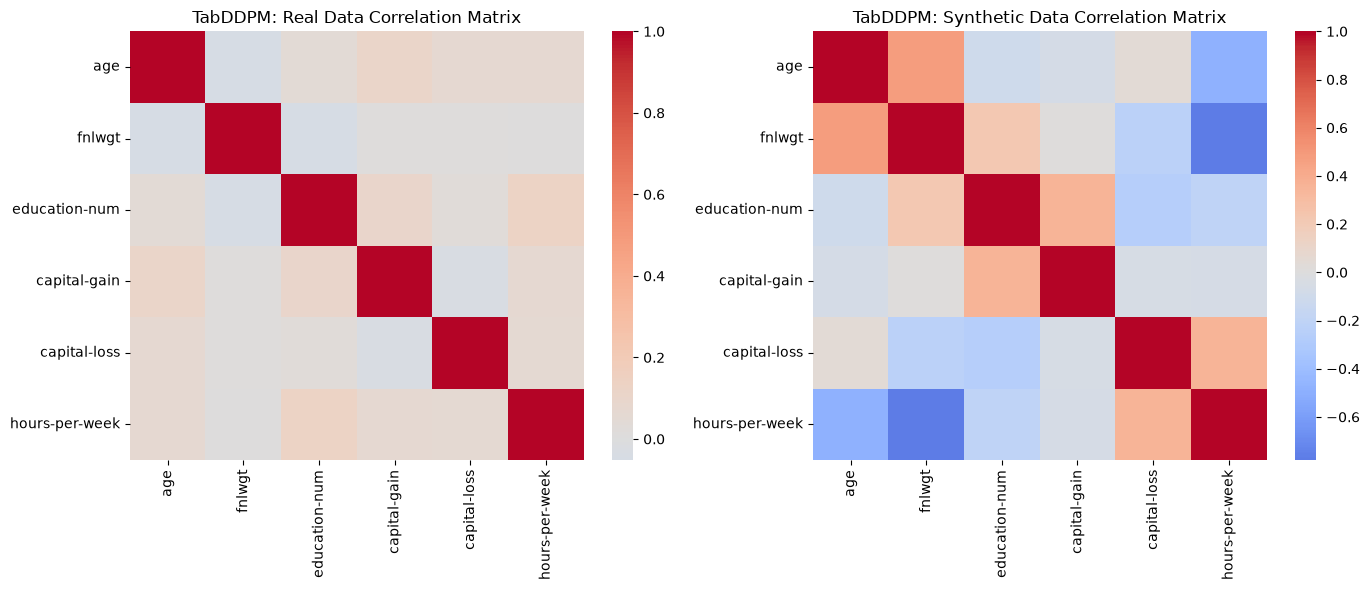

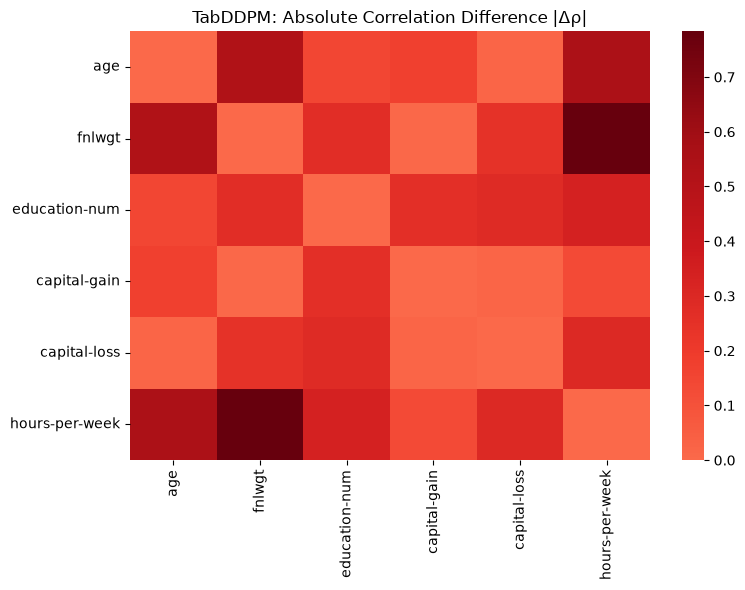

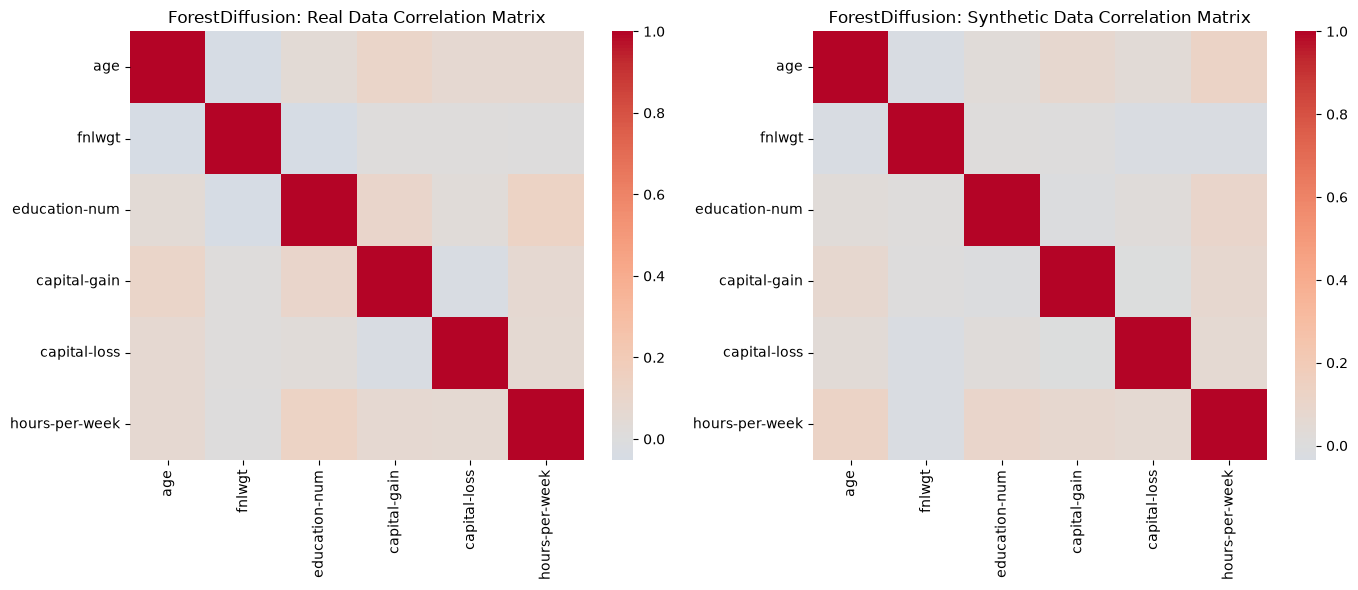

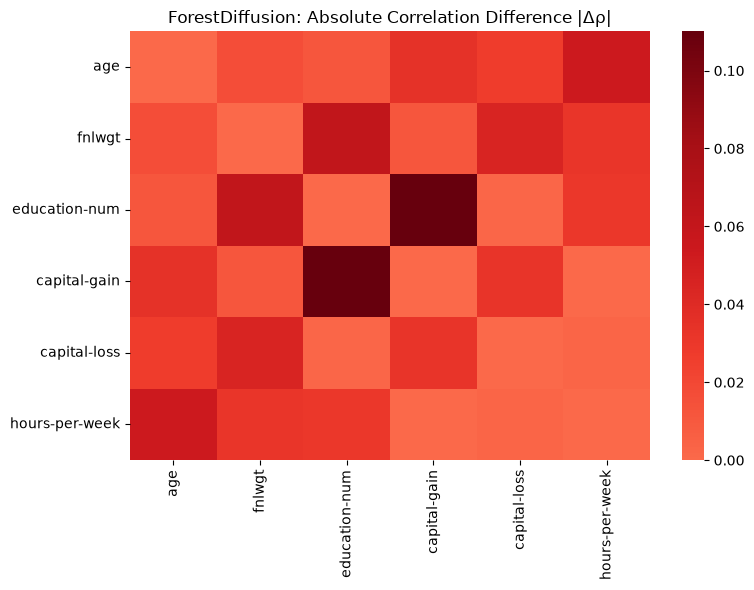

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "Group" if "Group" in data.columns else "Group"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# remove target if it ended up in numeric columns
if target_col in num_cols:
    num_cols.remove(target_col)

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # align columns safely
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]

    # keep only numeric columns for correlation
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]
    synth_corr = synth_df[synth_num_cols].corr()

    # make sure both matrices use the same order
    common_num_cols = [c for c in num_cols if c in synth_corr.columns]
    real_corr_plot = real_corr.loc[common_num_cols, common_num_cols]
    synth_corr_plot = synth_corr.loc[common_num_cols, common_num_cols]

    # 1) Real vs Synthetic correlation matrices
    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))
    sns.heatmap(real_corr_plot, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr_plot, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # 2) Absolute correlation difference heatmap
    diff_corr = (real_corr_plot - synth_corr_plot).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



TabDDPM - Global MMD (RBF): 0.359080


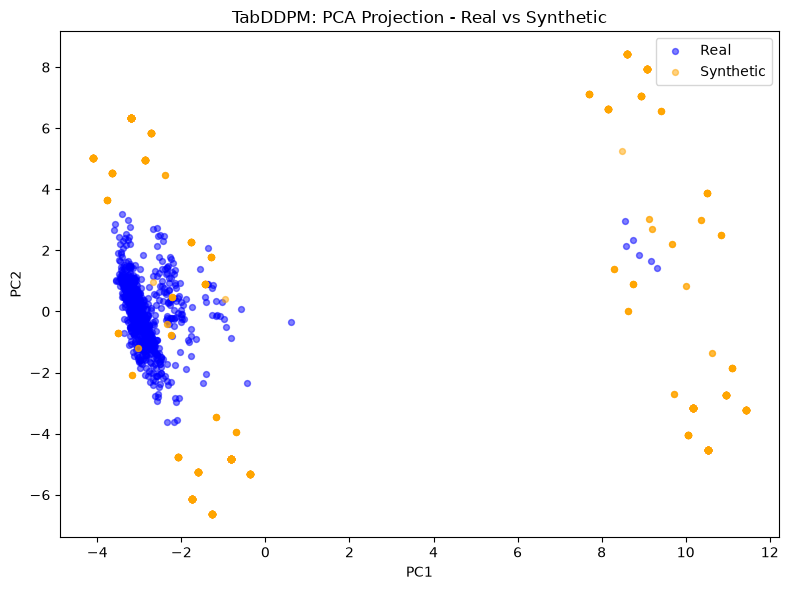

TabDDPM - Two-Sample Classifier Accuracy: 0.9983

ForestDiffusion - Global MMD (RBF): 0.006923


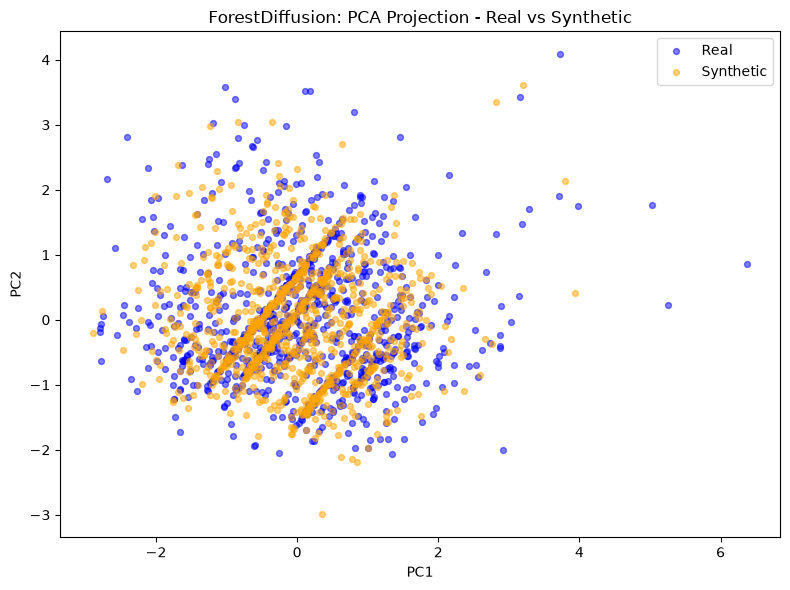

ForestDiffusion - Two-Sample Classifier Accuracy: 0.9400

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,ForestDiffusion,0.006923,0.940000
1,TabDDPM,0.359080,0.998333


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_order = ["TabDDPM", "ForestDiffusion"]

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2)) if med > 0 else 1.0
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

target_col = "Group" if "Group" in data.columns else "Group"
X_real_df = data.drop(columns=[target_col], errors="ignore")
X_real_df = X_real_df.select_dtypes(include=[np.number])

results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.drop(columns=[target_col], errors="ignore")
    synth_df = synth_df.select_dtypes(include=[np.number])

    common_cols = X_real_df.columns.intersection(synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 classifiers 

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

def clean_income_labels(y):
    """Map Adult income to binary 0/1 (handles strings and encoded numerics)."""
    if pd.api.types.is_numeric_dtype(y):
        return pd.to_numeric(y, errors="coerce").fillna(0).astype(int).clip(0, 1)
    y = y.astype(str).str.strip().str.replace(".", "", regex=False)
    y = y.replace({"<=50K": 0, ">50K": 1})
    return pd.to_numeric(y, errors="coerce").fillna(0).astype(int).clip(0, 1)

def evaluate_models(train_df, test_df, label_col, models=models, test_size=0.2, seed=42):
    def _encode_features(df, encoders=None):
        work = df.copy()
        y = clean_income_labels(work[label_col])
        X = work.drop(columns=[label_col])
        cat_cols = [
            c for c in X.columns
            if str(X[c].dtype) in ("object", "category", "string")
        ]
        num_cols = [c for c in X.columns if c not in cat_cols]
        out_encoders = {} if encoders is None else encoders
        for col in cat_cols:
            s = X[col].astype(str)
            if encoders is None:
                le = LabelEncoder()
                X[col] = le.fit_transform(s)
                out_encoders[col] = le
            else:
                le = encoders[col]
                mapping = {c: i for i, c in enumerate(le.classes_)}
                X[col] = s.map(mapping).fillna(0).astype(int)
        if num_cols:
            X[num_cols] = X[num_cols].fillna(X[num_cols].median(numeric_only=True))
        mask = y.notna()
        return X.loc[mask], y.loc[mask].astype(int), out_encoders

    X_train, y_train, encoders = _encode_features(train_df)
    X_test, y_test, _ = _encode_features(test_df, encoders=encoders)

    strat_train = y_train if y_train.nunique() > 1 else None
    strat_test = y_test if y_test.nunique() > 1 else None

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=strat_train
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=strat_test
    )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)


In [21]:
import pandas as pd

label_col = "income"

# Only the models you actually trained
model_order = ["TabDDPM", "ForestDiffusion"]

# First: evaluate on real data (TRTR)
trtr_results = evaluate_models(
    train_df=real_sample,
    test_df=real_sample,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    # Evaluate: train on synthetic, test on real (TSTR)
    tstr_results = evaluate_models(
        train_df=synthetic_outputs[synth_name],
        test_df=real_sample,
        label_col=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    # Compare with TRTR performance
    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    # AUC drop (loss of predictive power when training on synthetic)
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    # Optional drops if columns exist
    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]

    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

# Combine all synthetic-model comparisons into one table
combined_comparison = pd.concat(all_comparisons, ignore_index=True)

# Summary: average AUC drop by synthetic model (lower is better)
summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Us

TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
7,GradientBoost,0.845,0.586667,0.903920
8,AdaBoost,0.855,0.623377,0.902344
5,RandomForest,0.840,0.578947,0.868695
1,SVM-RBF,0.815,0.463768,0.868010
6,ExtraTrees,0.830,0.564103,0.845943
0,LogReg,0.825,0.533333,0.840735
3,NaiveBayes,0.800,0.444444,0.836143
9,MLP,0.815,0.584270,0.825932
2,KNN,0.800,0.512195,0.768435
4,DecisionTree,0.765,0.515464,0.681469


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Us

TabDDPM - TSTR (Train Synthetic, Test Real)


...

,Model,Accuracy,F1,AUC
8,AdaBoost,0.820,0.500000,0.896039
5,RandomForest,0.830,0.564103,0.867462
7,GradientBoost,0.800,0.428571,0.867119
0,LogReg,0.810,0.500000,0.829084
6,ExtraTrees,0.810,0.547619,0.826069
9,MLP,0.680,0.536232,0.775356
3,NaiveBayes,0.720,0.517241,0.753289
2,KNN,0.780,0.333333,0.723821
1,SVM-RBF,0.770,0.178571,0.713953
4,DecisionTree,0.735,0.430108,0.626096


ForestDiffusion - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
3,SVM-RBF,0.815,0.463768,0.868010,0.770,0.178571,0.713953,0.154057,0.285197,0.045,ForestDiffusion
6,NaiveBayes,0.800,0.444444,0.836143,0.720,0.517241,0.753289,0.082854,-0.072797,0.080,ForestDiffusion
9,DecisionTree,0.765,0.515464,0.681469,0.735,0.430108,0.626096,0.055373,0.085356,0.030,ForestDiffusion
7,MLP,0.815,0.584270,0.825932,0.680,0.536232,0.775356,0.050576,0.048038,0.135,ForestDiffusion
8,KNN,0.800,0.512195,0.768435,0.780,0.333333,0.723821,0.044613,0.178862,0.020,ForestDiffusion
0,GradientBoost,0.845,0.586667,0.903920,0.800,0.428571,0.867119,0.036801,0.158095,0.045,ForestDiffusion
4,ExtraTrees,0.830,0.564103,0.845943,0.810,0.547619,0.826069,0.019874,0.016484,0.020,ForestDiffusion
5,LogReg,0.825,0.533333,0.840735,0.810,0.500000,0.829084,0.011650,0.033333,0.015,ForestDiffusion
1,AdaBoost,0.855,0.623377,0.902344,0.820,0.500000,0.896039,0.006305,0.123377,0.035,ForestDiffusion
2,RandomForest,0.840,0.578947,0.868695,0.830,0.564103,0.867462,0.001234,0.014845,0.010,ForestDiffusion


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
0,ForestDiffusion,0.046334
1,TabDDPM,0.337315


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, exp


TabDDPM - TSTR


,Model,Accuracy,F1,AUC
9,MLP,0.545,0.427673,0.624589
2,KNN,0.770,0.115385,0.579359
4,DecisionTree,0.450,0.414894,0.565995
6,ExtraTrees,0.760,0.000000,0.551672
5,RandomForest,0.745,0.105263,0.545710
7,GradientBoost,0.615,0.206186,0.497876
8,AdaBoost,0.760,0.000000,0.481702
3,NaiveBayes,0.760,0.000000,0.416118
0,LogReg,0.760,0.000000,0.401453
1,SVM-RBF,0.760,0.000000,0.304002


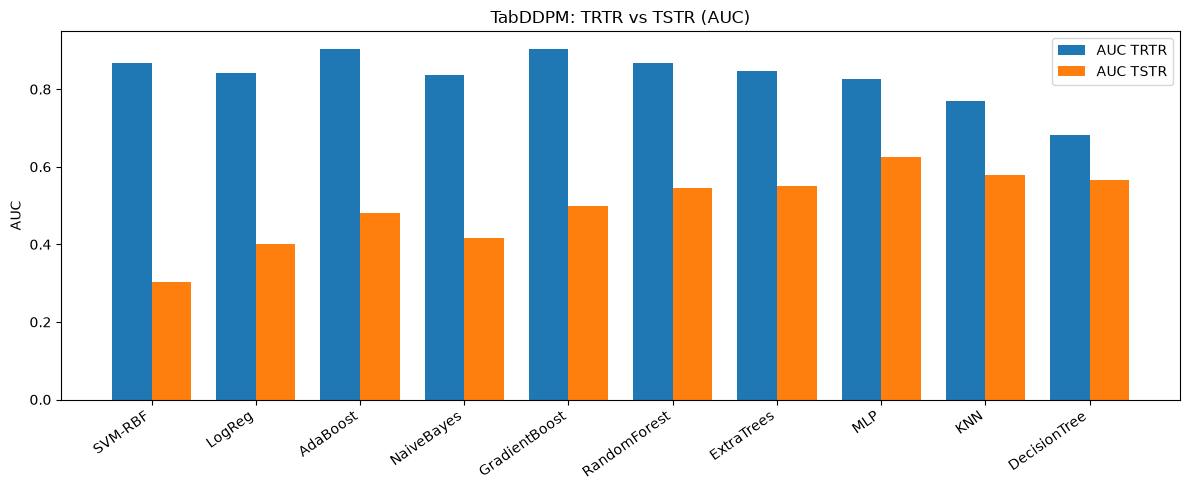

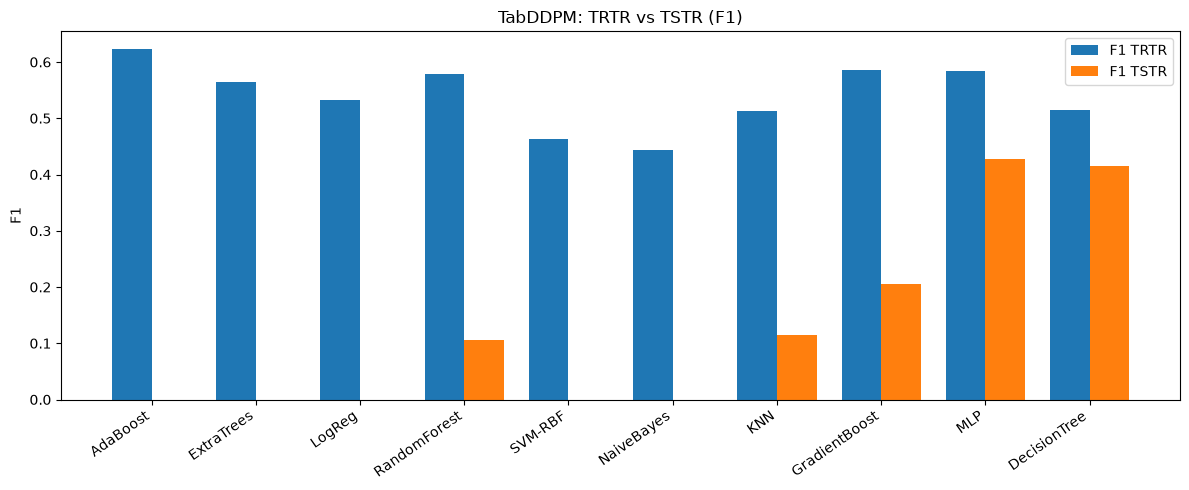

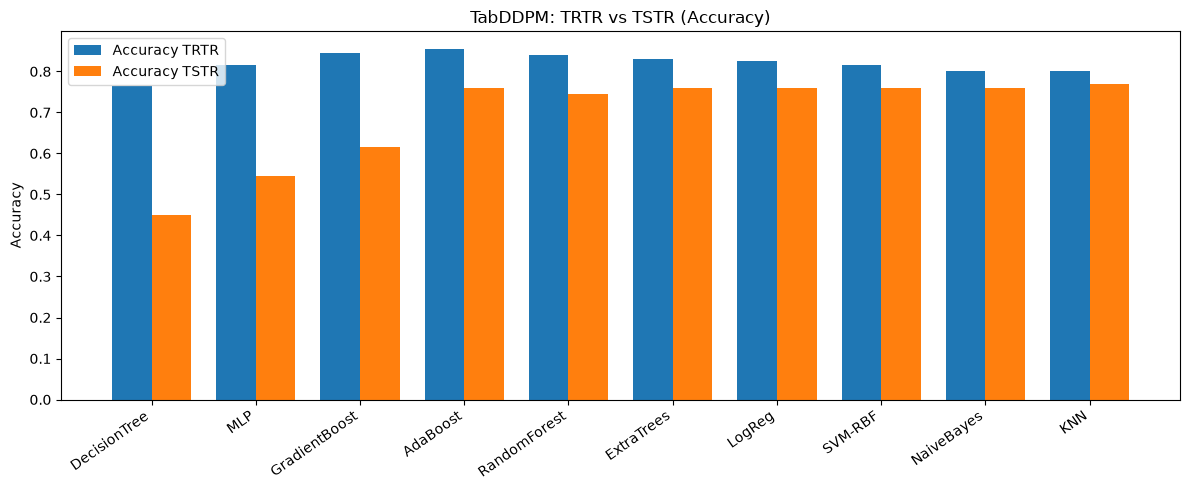

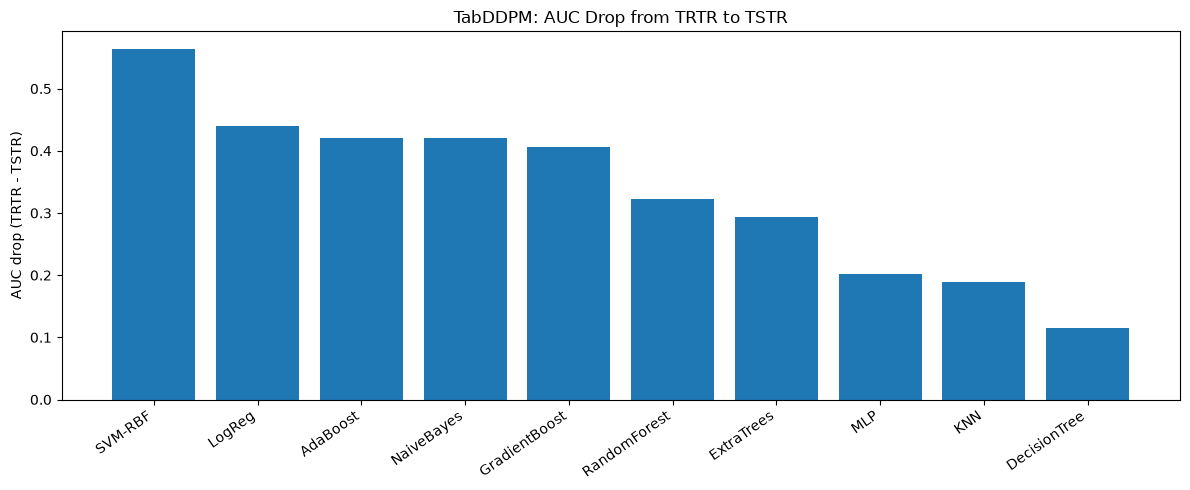

c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



ForestDiffusion - TSTR


,Model,Accuracy,F1,AUC
8,AdaBoost,0.820,0.500000,0.896039
5,RandomForest,0.830,0.564103,0.867462
7,GradientBoost,0.800,0.428571,0.867119
0,LogReg,0.810,0.500000,0.829084
6,ExtraTrees,0.810,0.547619,0.826069
9,MLP,0.680,0.536232,0.775356
3,NaiveBayes,0.720,0.517241,0.753289
2,KNN,0.780,0.333333,0.723821
1,SVM-RBF,0.770,0.178571,0.713953
4,DecisionTree,0.735,0.430108,0.626096


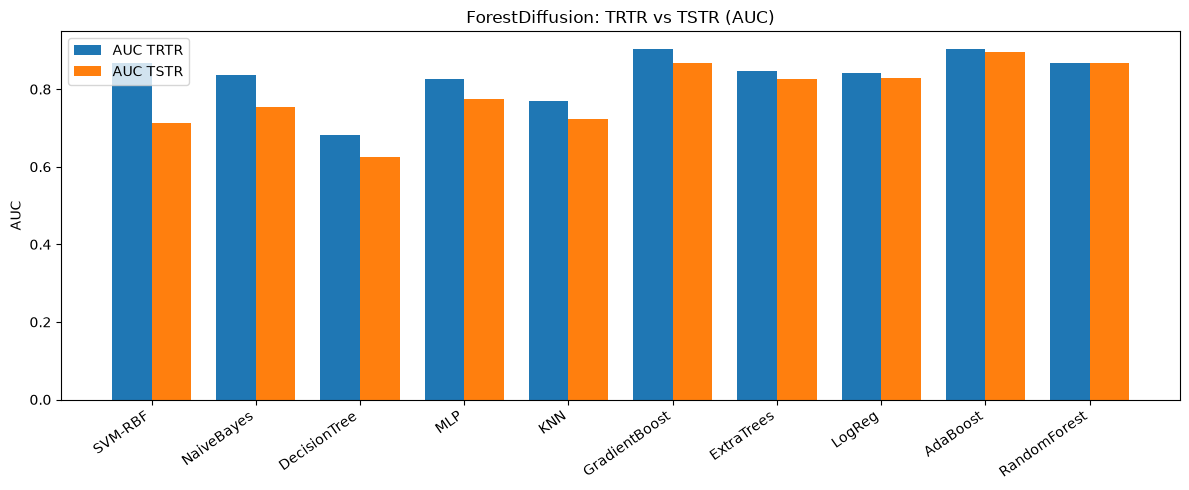

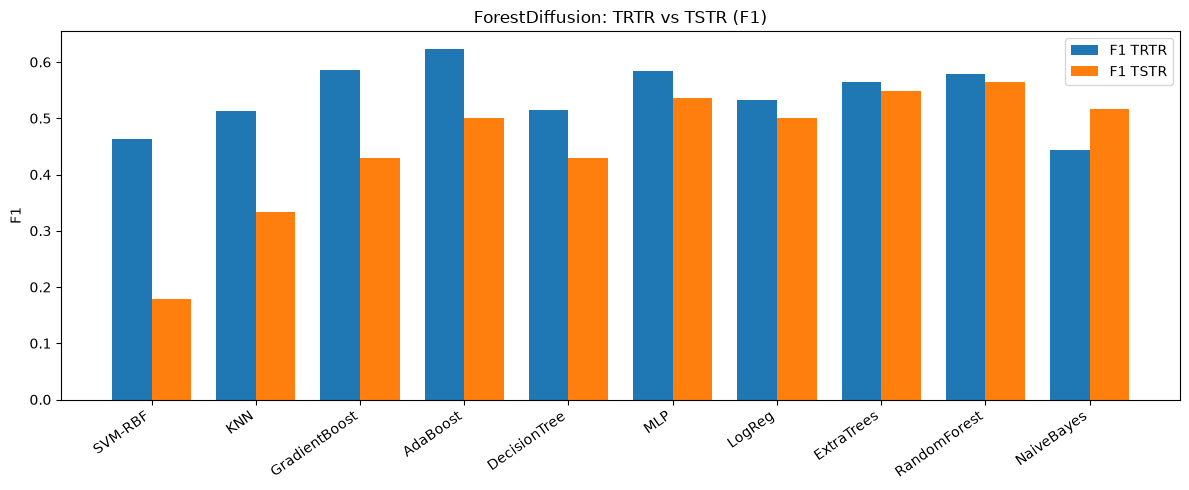

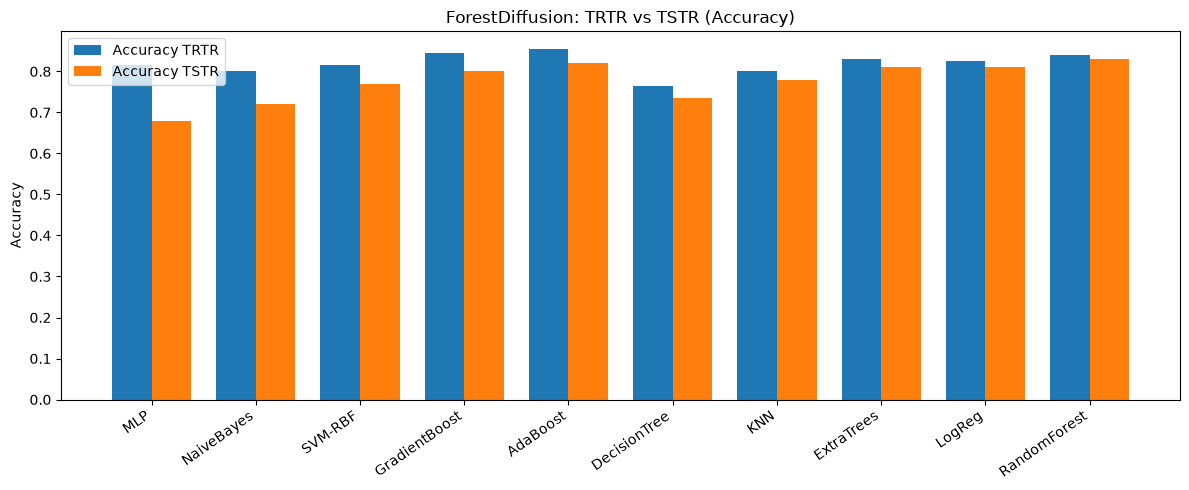

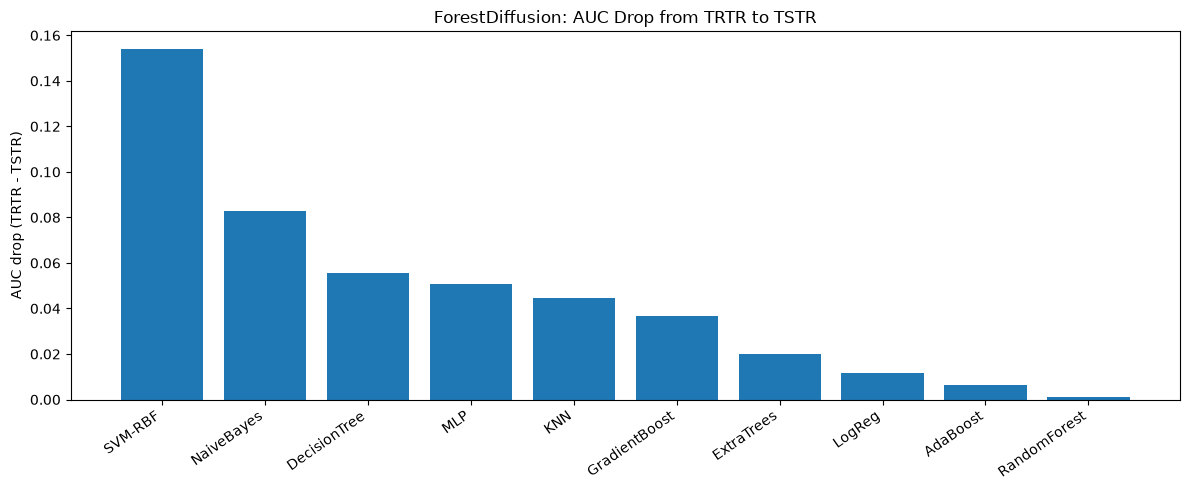


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
0,ForestDiffusion,0.046334
1,TabDDPM,0.337315


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

# Fixed for Adult dataset
label_col = "income"
model_order = ["TabDDPM", "ForestDiffusion"]

# Clean and prepare real data
data_eval = real_sample.copy()
data_eval[label_col] = clean_income_labels(data_eval[label_col])  # From previous cell

# Clean synthetic data
synthetic_eval = {}
for name in model_order:
    df = synthetic_outputs[name].copy()
    if label_col in df.columns:
        df[label_col] = clean_income_labels(df[label_col])
    synthetic_eval[name] = df

# TRTR baseline
trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_eval[synth_name],
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    # Plot comparisons
    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

# Summary table
combined_comparison = pd.concat(all_comp, ignore_index=True)
summary_auc = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("\nAverage AUC drop by synthetic generator (lower is better):")
display(summary_auc)


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavio

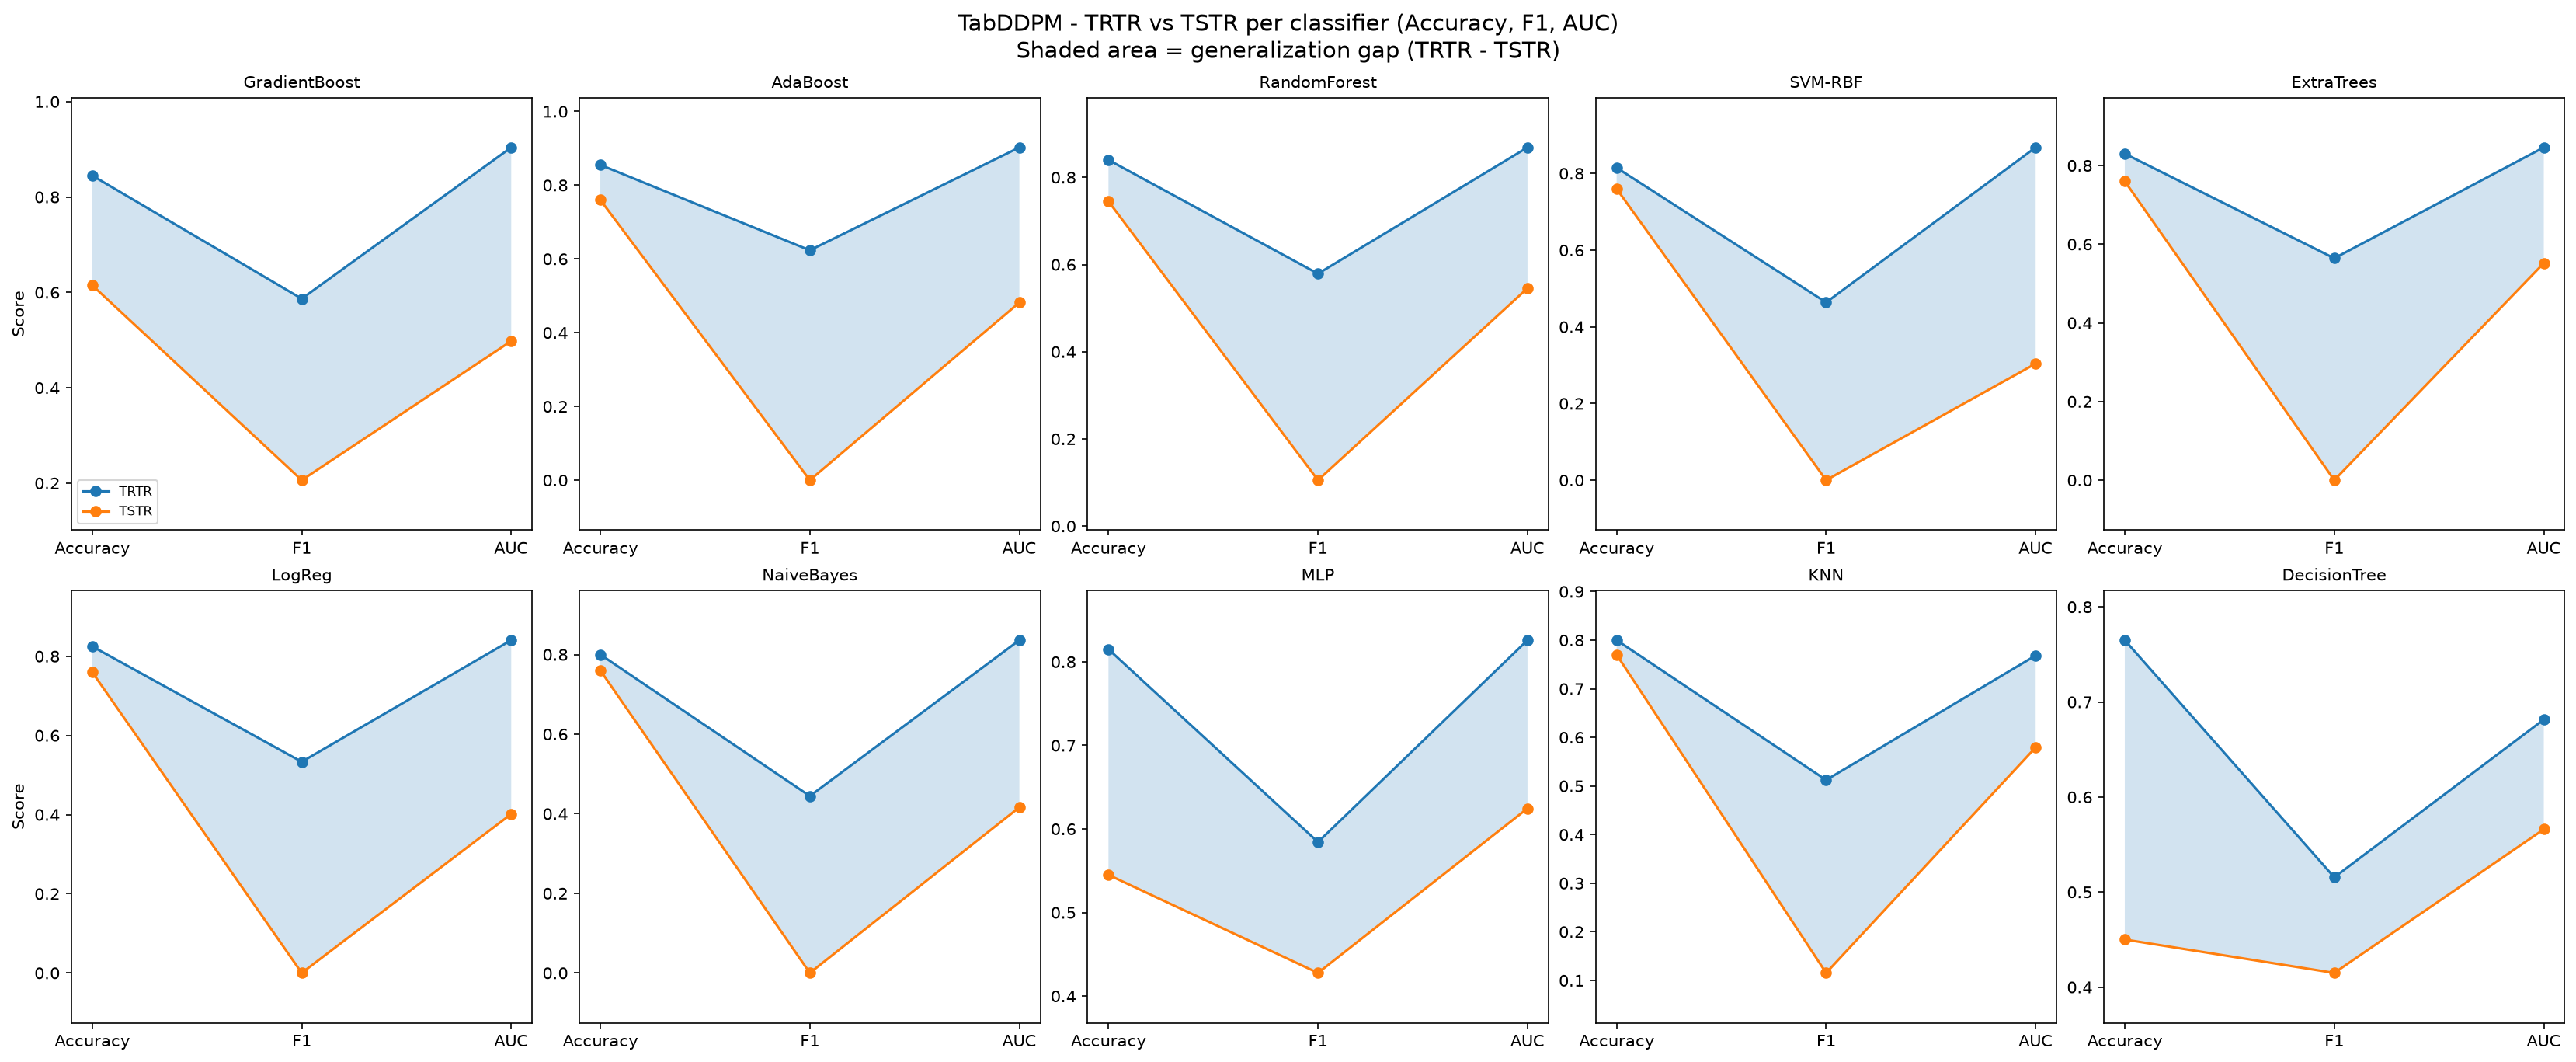

C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


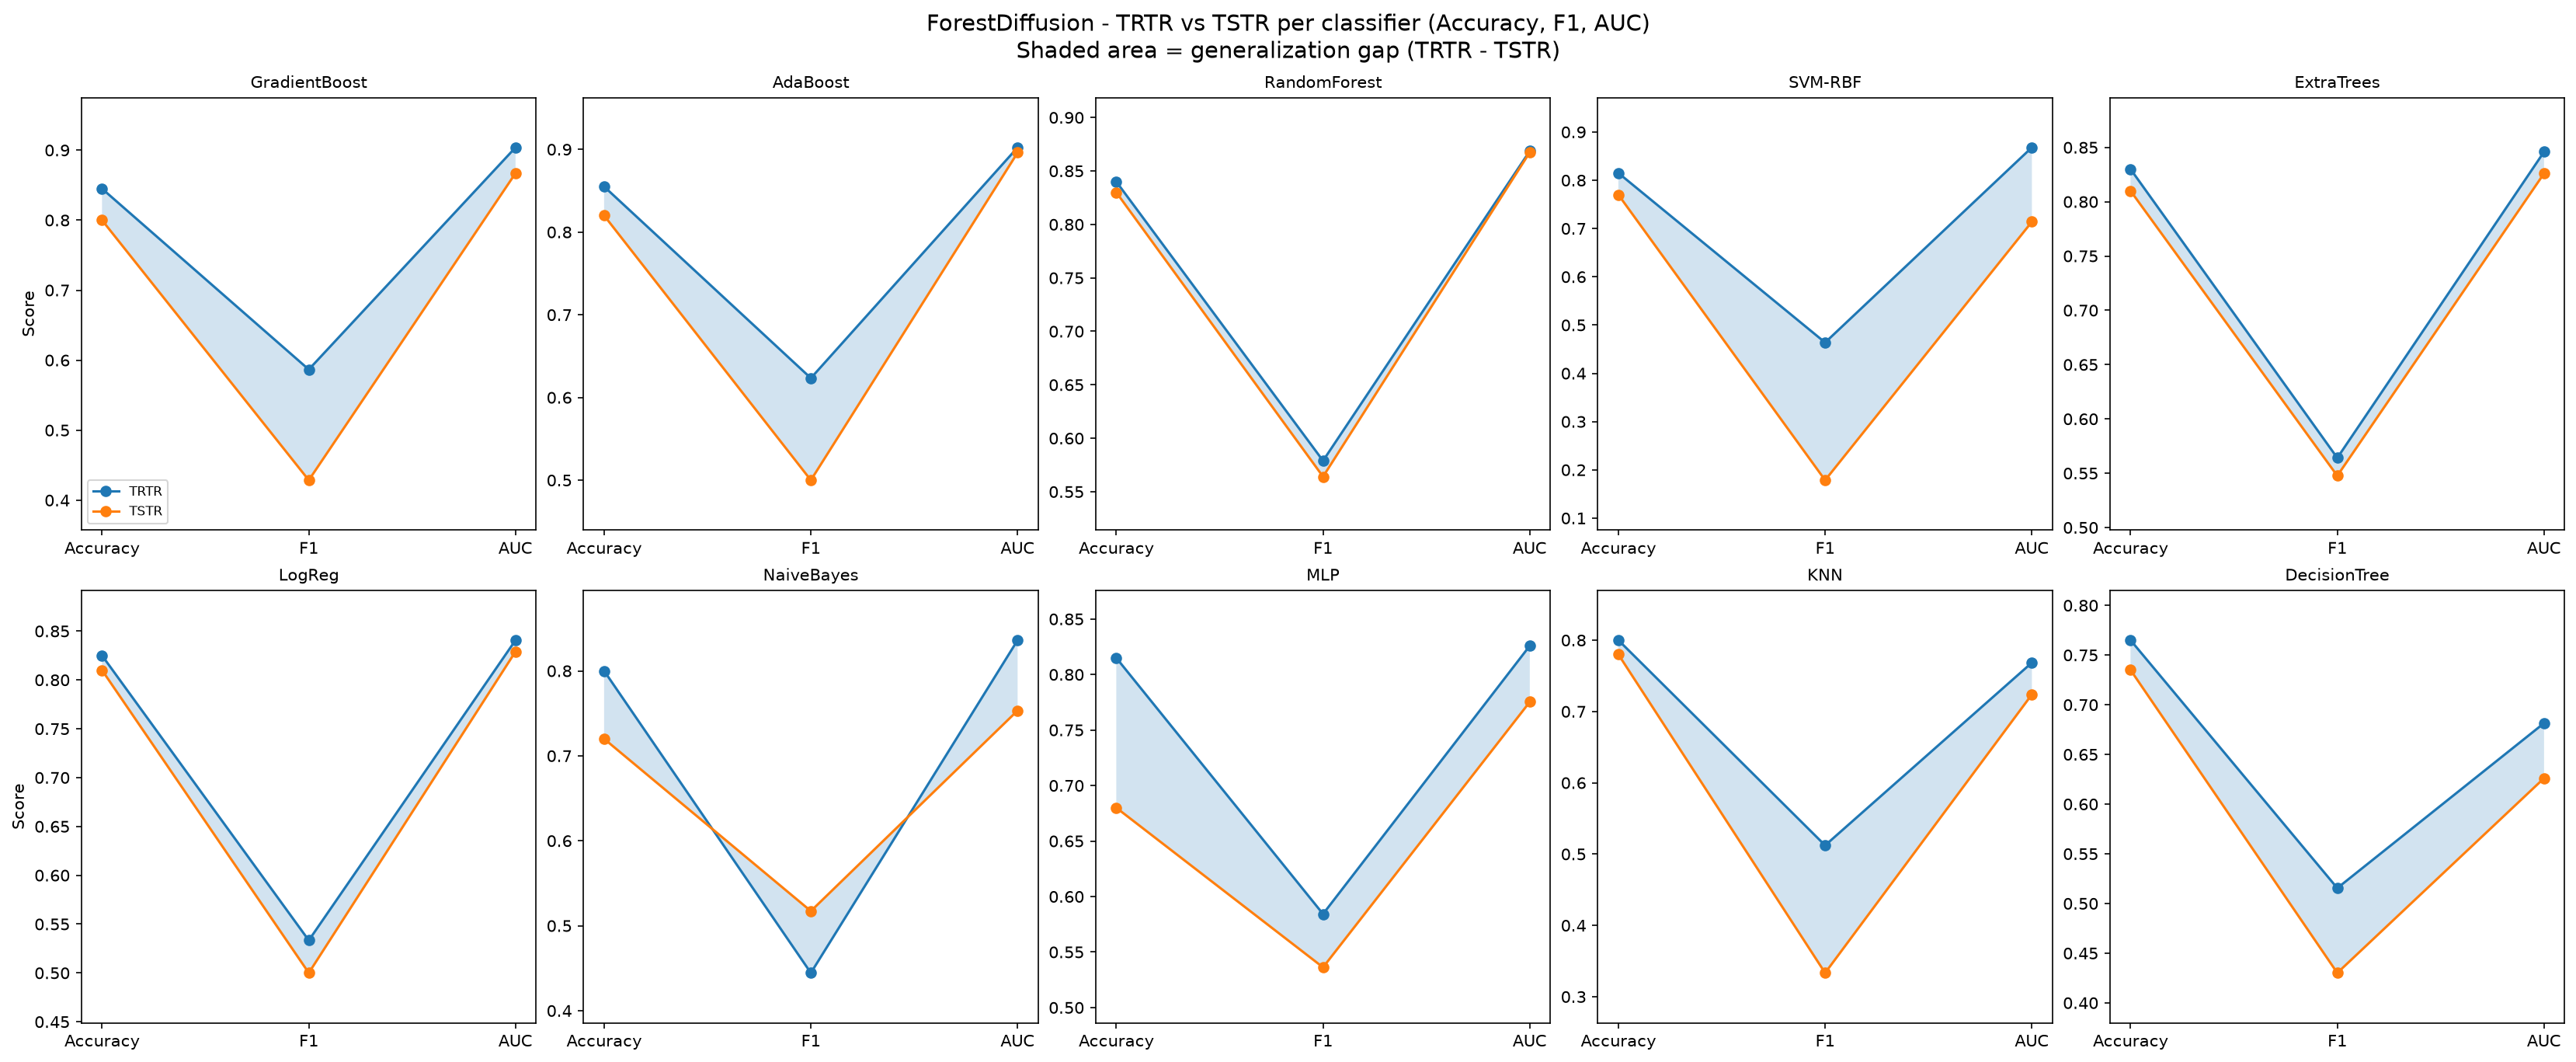

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

# Fixed for Adult dataset + clean labels
label_col = "income"
generators = ["TabDDPM", "ForestDiffusion"]

# Clean and prepare real data (using clean_income_labels from previous cell)
data_eval = real_sample.copy()
data_eval[label_col] = clean_income_labels(data_eval[label_col])

# TRTR baseline
trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

for gen in generators:
    synth_eval = synthetic_outputs[gen].copy()
    if label_col in synth_eval.columns:
        synth_eval[label_col] = clean_income_labels(synth_eval[label_col])

    tstr_results = evaluate_models(
        train_df=synth_eval,
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,787.660693,83.129493,259.866866
1,ForestDiffusion,15.091778,1.366754,21.832922


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\4140255185.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\4140255185.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\4140255185.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Mo

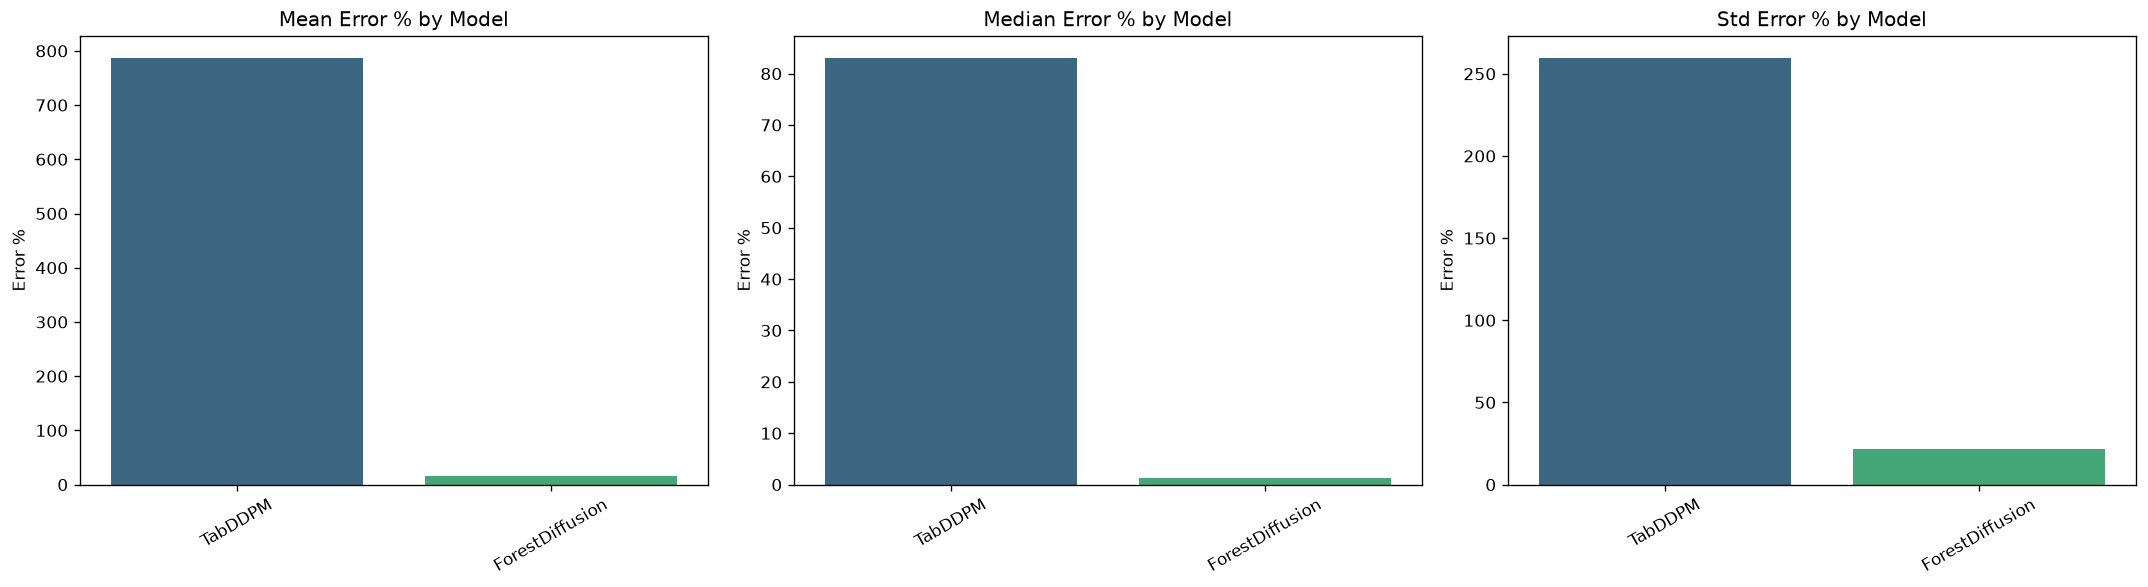

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    
    # Align columns and handle NaN
    synth_df = synth_df[num_cols].fillna(synth_df[num_cols].median())
    real_df_aligned = real_df[num_cols].fillna(real_df[num_cols].median())
    
    real_means = real_df_aligned.mean()
    synth_means = synth_df.mean()

    real_stds = real_df_aligned.std(ddof=1)
    synth_stds = synth_df.std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


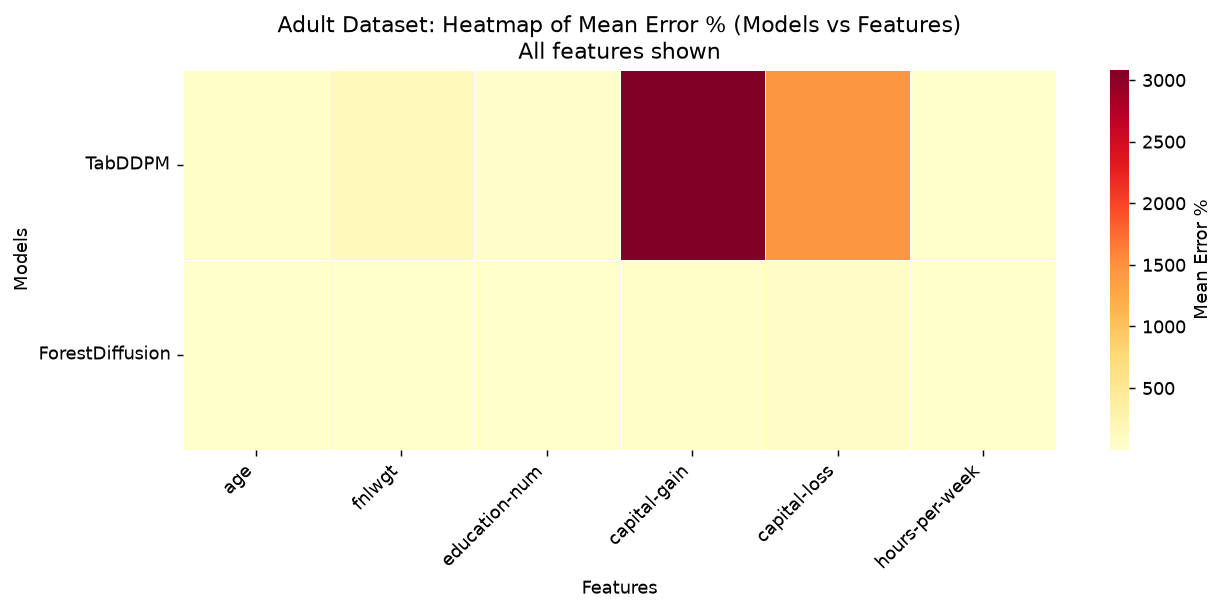

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

# Create heatmap from feature_error_by_model (previous cell)
heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Adult Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


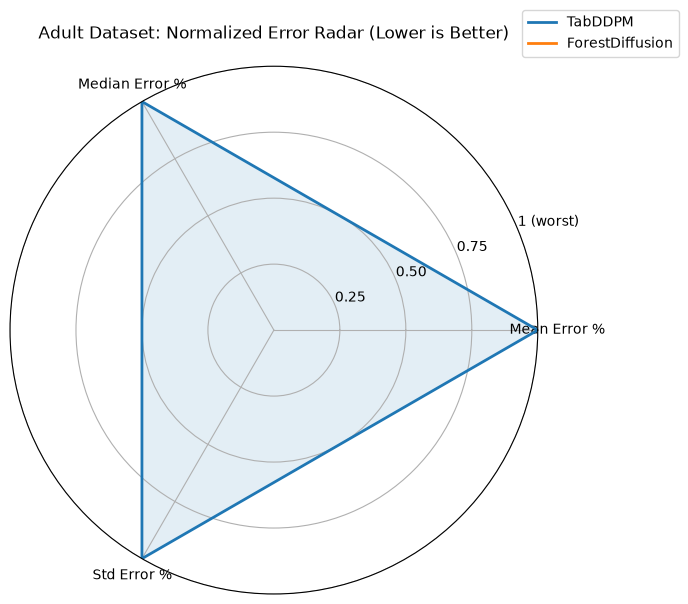

,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,1.0,1.0,1.0
1,ForestDiffusion,0.0,0.0,0.0


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requires summary_df with columns:
# ["Model", "Mean Error %", "Median Error %", "Std Error %"]
# from previous statistical moments cell

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best / lowest error, 1 = worst / highest error)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Adult Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,ForestDiffusion,38.0,28.0,91
1,TabDDPM,76.5,37.0,274


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\1891053758.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")


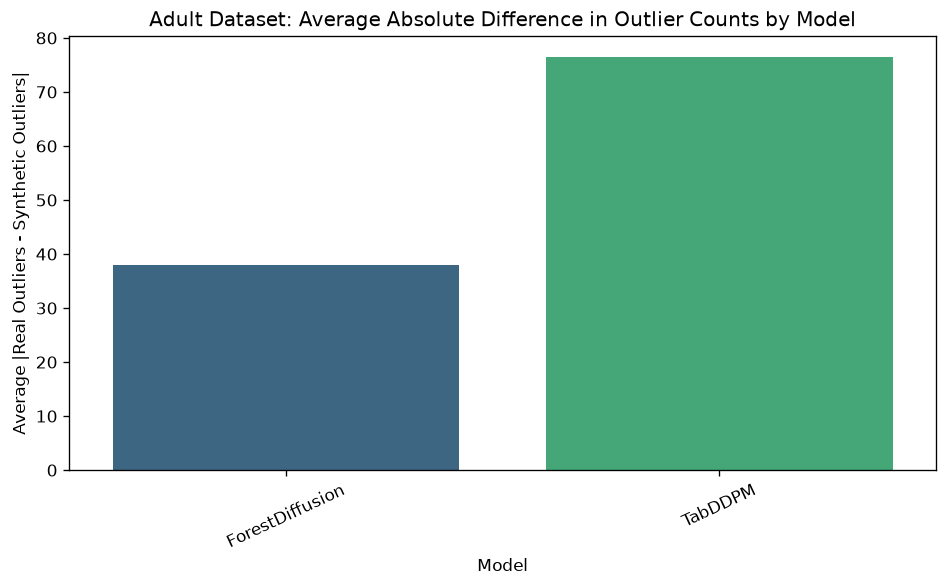

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

# Handle NaN before outlier detection
real_df_clean = real_df[num_cols].fillna(real_df[num_cols].median())
real_outliers = {c: outlier_count_iqr(real_df_clean[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_outputs[model].copy()
    
    # Clean synthetic data and align columns
    synth_df_clean = synth_df[num_cols].fillna(synth_df[num_cols].median())
    synth_num_cols = [c for c in num_cols if c in synth_df_clean.columns]
    
    synth_outliers = {c: outlier_count_iqr(synth_df_clean[c]) for c in synth_num_cols}

    feat_df = pd.DataFrame({
        "Feature": synth_num_cols,
        "Real_Outliers": [real_outliers[c] for c in synth_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in synth_num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Adult Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [28]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(real_df, synth_df, num_cols=None, target_col=None):
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col is None:
        target_col = "income"
    if target_col in num_cols:
        num_cols.remove(target_col)

    # Handle NaN before normalization
    R_clean = real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)
    S_clean = synth_df[num_cols].fillna(synth_df[num_cols].median()).to_numpy(dtype=float)
    
    return normalize_rows(R_clean) @ normalize_rows(S_clean).T

# Fixed for Adult dataset pipeline
synthetic_data = synthetic_outputs

cosine_results = {}
cosine_dfs = {}

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = normalize_rows(real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float))

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"Warning: {model_name} not found. Available: {list(synthetic_data.keys())}")
        continue

    synth_df = synthetic_data[model_name].copy()
    
    # Clean and align columns
    synth_clean = synth_df[num_cols].fillna(synth_df[num_cols].median())
    print(f"Building cosine similarity for {model_name}...")

    synth_matrix = normalize_rows(synth_clean.to_numpy(dtype=float))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(f"{model_name} cosine sample:\n", cosine_df.round(3), "\n")

display(pd.DataFrame(cosine_results).T)


Building cosine similarity for TabDDPM...
TabDDPM cosine sample:
         S1     S2   S3   S4     S5     S6     S7     S8   S9    S10
R1   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R2   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R3   0.994  0.994  1.0  1.0  0.233  0.233  0.994  0.994  1.0  0.994
R4   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R5   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R6   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R7   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R8   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R9   0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991
R10  0.991  0.991  1.0  1.0  0.204  0.204  0.991  0.991  1.0  0.991 

Building cosine similarity for ForestDiffusion...
ForestDiffusion cosine sample:
       S1   S2   S3   S4   S5   S6   S7   S8   S9  S10
R1   1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0

,avg_cosine,max_cosine
TabDDPM,0.866715,1.0
ForestDiffusion,0.998400,1.0


In [29]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    target_col = "Group" if "Group" in real_data.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


TabDDPM - Top 10 Real -> Synthetic Matchings
01. R622 -> S472   cosine similarity = 1.0000
02. R911 -> S472   cosine similarity = 1.0000
03. R602 -> S472   cosine similarity = 1.0000
04. R884 -> S472   cosine similarity = 1.0000
05. R443 -> S472   cosine similarity = 1.0000
06. R867 -> S472   cosine similarity = 1.0000
07. R947 -> S472   cosine similarity = 1.0000
08. R610 -> S46   cosine similarity = 1.0000
09. R922 -> S472   cosine similarity = 1.0000
10. R221 -> S472   cosine similarity = 1.0000

ForestDiffusion - Top 10 Real -> Synthetic Matchings
01. R268 -> S333   cosine similarity = 1.0000
02. R143 -> S795   cosine similarity = 1.0000
03. R644 -> S996   cosine similarity = 1.0000
04. R853 -> S947   cosine similarity = 1.0000
05. R865 -> S915   cosine similarity = 1.0000
06. R802 -> S647   cosine similarity = 1.0000
07. R300 -> S529   cosine similarity = 1.0000
08. R235 -> S422   cosine similarity = 1.0000
09. R244 -> S806   cosine similarity = 1.0000
10. R707 -> S417   cosine s

In [30]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    target_col = "Group" if "Group" in real_df.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()

# Use your actual synthetic DataFrames here
# Use TabDDPM and ForestDiffusion synthetic outputs
synthetic_data = {
    "TabDDPM": synthetic_outputs["TabDDPM"],
    "ForestDiffusion": synthetic_outputs["ForestDiffusion"],
}

results = {}

for name, synth_df in synthetic_data.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features)")
    print(f"==============================")

    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common].copy()

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

summary_df = pd.DataFrame(
    [{"Model": name, "Avg_Hungarian_Cosine": info["avg_similarity"]} for name, info in results.items()]
).sort_values("Avg_Hungarian_Cosine", ascending=False)

display(summary_df)



TabDDPM: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.8739

R913 <-> S79   cosine similarity = 1.0000
R273 <-> S708   cosine similarity = 1.0000
R87 <-> S322   cosine similarity = 1.0000
R330 <-> S836   cosine similarity = 1.0000
R365 <-> S587   cosine similarity = 1.0000
R619 <-> S36   cosine similarity = 1.0000
R963 <-> S684   cosine similarity = 1.0000
R580 <-> S454   cosine similarity = 1.0000
R851 <-> S484   cosine similarity = 1.0000
R420 <-> S64   cosine similarity = 1.0000

ForestDiffusion: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9998

R116 <-> S307   cosine similarity = 1.0000
R414 <-> S986   cosine similarity = 1.0000
R603 <-> S301   cosine similarity = 1.0000
R551 <-> S666   cosine similarity = 1.0000
R658 <-> S797   cosine similarity = 1.0000
R712 <-> S595   cosine similarity = 1.0000
R1000 <-> S54   cosine similarity = 1.0000
R162 <-> S988   cosine similarity = 1.0000
R508

,Model,Avg_Hungarian_Cosine
1,ForestDiffusion,0.999760
0,TabDDPM,0.873941


In [31]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

target_col = "Group" if "Group" in real_df.columns else "Group"
if target_col in feature_cols:
    feature_cols.remove(target_col)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

model_order = ["TabDDPM", "ForestDiffusion"]  # ← FIXED: Match your results keys
output_file = "Adult_Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            print(f"Skipping {model_name}: no Hungarian results found")
            continue
        if model_name not in synth_source:
            print(f"Skipping {model_name}: no synthetic data found")
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        display(summary_df)  # ← FIXED: Moved inside with block

print(f"Saved: {output_file}")


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
1,ForestDiffusion,1000,0.999760,1.000000,0.961976,1.0
0,TabDDPM,1000,0.873941,0.993655,0.203543,1.0


Saved: Adult_Hungarian_Matchings_All_Models.xlsx


# 7. Mahalanobis distance with Hungrain Mapping  

In [32]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

target_col = "Group" if "Group" in data.columns else "Group"

data_numeric = data.select_dtypes(include=[np.number]).dropna().copy()
if target_col in data_numeric.columns:
    data_numeric = data_numeric.drop(columns=[target_col])

real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (6,), Inv_cov shape: (6, 6)


In [33]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# First compute real distribution statistics (you need these first)
real_numeric = data[num_cols].to_numpy(dtype=float)
mu_real = np.mean(real_numeric, axis=0)
cov_real = np.cov(real_numeric, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))  # Stabilize

# Smart synthetic source detection (same as your Excel cell)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

target_col = "Group" if "Group" in data.columns else "Group"
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

mahalanobis_results = {}
available_models = []

for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)
        
        # Compute Mahalanobis distances
        dists = [mahalanobis(x, mu_real, inv_cov_real) for x in synth_numeric]
        dists = np.array(dists)
        
        mahalanobis_results[name] = {
            "mean": float(np.mean(dists)),
            "median": float(np.median(dists)),
            "std": float(np.std(dists)),
            "min": float(np.min(dists)),
            "max": float(np.max(dists)),
            "distances": dists,
        }
        available_models.append(name)
        print(f"✓ {name}: mean Mahalanobis = {np.mean(dists):.3f}")
    else:
        print(f"✗ {name} not found in synthetic source. Available: {list(synth_source.keys())}")

# Create summary only for available models
if mahalanobis_results:
    summary = pd.DataFrame({
        name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
        for name, r in mahalanobis_results.items()
    }, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T
    
    summary.index.name = "Model"
    summary = summary.sort_values("mean_dist")
    
    print("Mahalanobis distance to real distribution (lower is better):")
    display(summary)
else:
    print("No valid synthetic data found for Mahalanobis analysis.")


✓ TabDDPM: mean Mahalanobis = 10.941
✓ ForestDiffusion: mean Mahalanobis = 1.675
Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
ForestDiffusion,1.674703,1.533015,0.973871,0.302001,12.546637
TabDDPM,10.941223,9.630982,3.309843,4.695080,15.834896


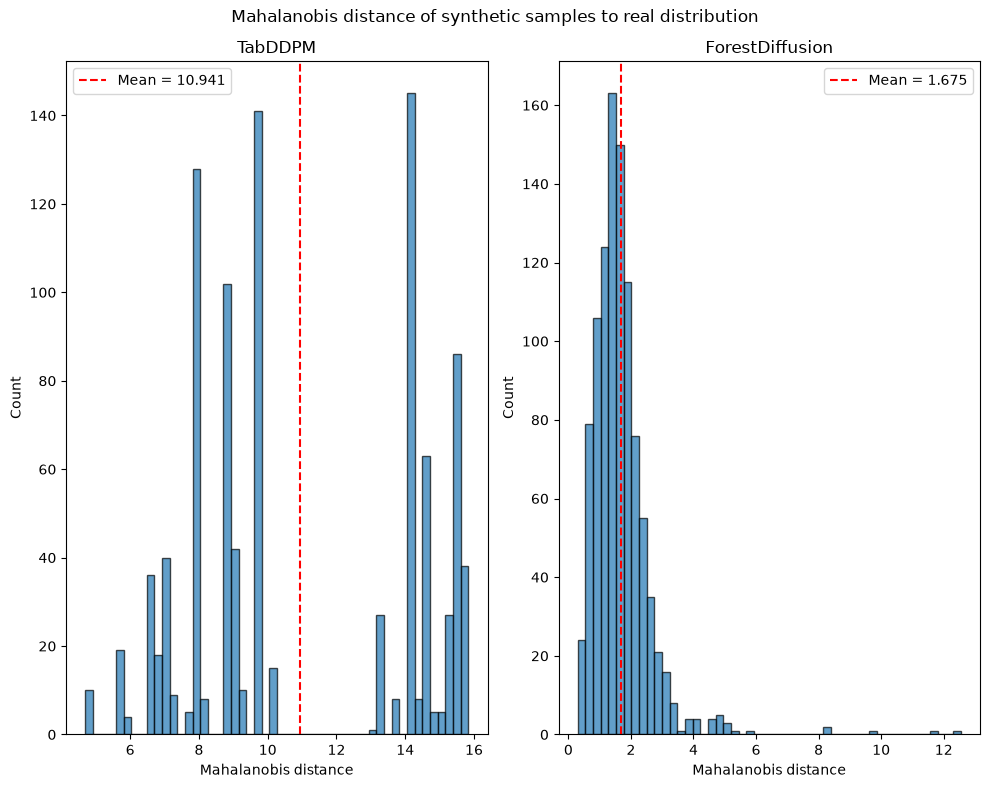

In [34]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(model_order), figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [35]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Fixed for Adult dataset pipeline
target_col = "income"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# Clean data and compute covariance inverse
real_matrix = real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)
cov_real = np.cov(real_matrix, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Map your synthetic outputs (from generation pipeline)
synthetic_data = synthetic_outputs

model_order = ["TabDDPM", "ForestDiffusion"]

for name in model_order:
    if name in synthetic_data:
        synth_df = synthetic_data[name][num_cols].copy()
        synth_numeric = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
        
        n_matches = min(real_matrix.shape[0], synth_numeric.shape[0])
        print(f"✓ Processing {name} ({n_matches} matches from {synth_numeric.shape[0]} synth samples)")
        
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic data. Available: {list(synthetic_data.keys())}")

# Summary table
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match", 
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Adult Dataset: Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM (1000 matches from 1000 synth samples)
✓ Processing ForestDiffusion (1000 matches from 1000 synth samples)
Adult Dataset: Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,0.683576,0.477761,0.874151,10.677479,1000.0
TabDDPM,10.024067,9.185727,3.994602,16.151901,1000.0


In [36]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
target_col = "Group" if "Group" in data.columns else "Group"
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)
        
        # REMOVED size check - Hungarian handles rectangular matrices automatically
        n_real, n_synth = real_matrix.shape[0], synth_numeric.shape[0]
        n_matches = min(n_real, n_synth)
        print(f"✓ Processing {name}: {n_real} real vs {n_synth} synth → {n_matches} matches")
        
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_real": n_real,
            "n_synth": n_synth,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")
    
    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM: 1000 real vs 1000 synth → 1000 matches
✓ Processing ForestDiffusion: 1000 real vs 1000 synth → 1000 matches
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,0.683576,0.477761,0.874151,10.677479,1000.0
TabDDPM,10.024067,9.185727,3.994602,16.151901,1000.0


In [37]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

# Smart synthetic source detection (same as previous cells)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

# Use same numeric columns as previous Mahalanobis cell
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
target_col = "Group" if "Group" in data.columns else "Group"
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

greedy_results = {}
comparison_rows = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source and name in hungarian_results:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)
        
        print(f"✓ Processing {name}: {real_matrix.shape[0]} real vs {synth_numeric.shape[0]} synth")
        
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        total_g, mean_g, _ = greedy_one_to_one_matching(D)

        greedy_results[name] = {
            "total_distance": total_g,
            "mean_distance": mean_g
        }

        # Compare with Hungarian results
        h_total = hungarian_results[name]["total_distance"]
        h_mean = hungarian_results[name]["mean_distance_per_match"]

        comparison_rows.append({
            "Model": name,
            "Greedy total": total_g,
            "Hungarian total": h_total,
            "Greedy mean": mean_g,
            "Hungarian mean": h_mean,
            "Total diff (Greedy - Hungarian)": total_g - h_total,
            "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
        })
        print(f"  Greedy mean: {mean_g:.4f} vs Hungarian: {h_mean:.4f} (diff: {mean_g-h_mean:.4f})")
    else:
        print(f"✗ Skipping {name} (missing data or Hungarian results)")

# Greedy summary
if greedy_results:
    greedy_summary = pd.DataFrame({
        name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
        for name in greedy_results
    }, index=["total_distance", "mean_distance"]).T
    greedy_summary.index.name = "Model"
    
    print("Greedy one-to-one matching (Mahalanobis distance):")
    display(greedy_summary)

    print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
    comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
    display(comparison_df)
else:
    print("No valid models for greedy matching.")


✓ Processing TabDDPM: 1000 real vs 1000 synth
  Greedy mean: 10.1260 vs Hungarian: 10.0241 (diff: 0.1019)
✓ Processing ForestDiffusion: 1000 real vs 1000 synth
  Greedy mean: 0.7951 vs Hungarian: 0.6836 (diff: 0.1115)
Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
TabDDPM,10125.957231,10.125957
ForestDiffusion,795.102602,0.795103



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
TabDDPM,10125.957231,10024.066823,10.125957,10.024067,101.890408,0.101890
ForestDiffusion,795.102602,683.575884,0.795103,0.683576,111.526718,0.111527


In [38]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Fixed for Adult dataset pipeline
real_df = real_sample.copy()
target_col = "income"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)

# Covariance with regularization (pinv is better than inv for stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models from generation pipeline
model_order = ["TabDDPM", "ForestDiffusion"]
hungarian_results = {}

synthetic_data = synthetic_outputs

for model_name in model_order:
    if model_name in synthetic_data:
        synth_df = synthetic_data[model_name][feature_cols].copy()
        X_synth = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
        
        print(f"✓ Processing {model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        
        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian handles rectangular matrices automatically
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]
        
        hungarian_results[model_name] = {
            "row_ind": row_ind, 
            "col_ind": col_ind, 
            "dists": dists
        }

        # Top matches
        order = np.argsort(dists)
        top_k = min(20, len(order))
        print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
        for rank, k in enumerate(order[:top_k], 1):
            print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")
    else:
        print(f"✗ {model_name} not in synthetic data. Available: {list(synthetic_data.keys())}")

# Summary stats
if hungarian_results:
    summary_stats = pd.DataFrame({
        model_name: {
            "mean_dist": np.mean(hungarian_results[model_name]["dists"]),
            "median_dist": np.median(hungarian_results[model_name]["dists"]),
            "min_dist": np.min(hungarian_results[model_name]["dists"])
        }
        for model_name in hungarian_results
    }).T.sort_values("mean_dist")
    print("\nAdult Dataset: Summary Mahalanobis distances (lower is better):")
    display(summary_stats)


✓ Processing TabDDPM: 1000 real vs 1000 synth

TabDDPM - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R422 -> S88   distance = 1.8285
02. R382 -> S159   distance = 1.8448
03. R269 -> S265   distance = 1.9306
04. R340 -> S187   distance = 2.1886
05. R820 -> S921   distance = 2.1928
06. R236 -> S706   distance = 2.2511
07. R571 -> S89   distance = 2.2954
08. R857 -> S297   distance = 2.4078
09. R727 -> S577   distance = 2.4379
10. R765 -> S254   distance = 2.4504
11. R303 -> S840   distance = 2.5496
12. R333 -> S491   distance = 2.6165
13. R293 -> S396   distance = 2.6467
14. R570 -> S629   distance = 2.7076
15. R468 -> S786   distance = 2.7511
16. R318 -> S308   distance = 2.8916
17. R16 -> S572   distance = 2.9237
18. R665 -> S176   distance = 2.9247
19. R21 -> S711   distance = 2.9469
20. R277 -> S722   distance = 3.1521
✓ Processing ForestDiffusion: 1000 real vs 1000 synth

ForestDiffusion - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R86 -> S547   

,mean_dist,median_dist,min_dist
ForestDiffusion,0.683576,0.477761,0.011377
TabDDPM,10.024067,9.185727,1.828477


In [39]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd

# Direct synthetic source (your pipeline)
synth_source = synthetic_outputs

# Fixed for Adult dataset pipeline
real_df = real_sample.copy()
target_col = "income"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

# Clean data before matrix operations
X_real = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)

# Covariance with regularization (pinv for numerical stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models from generation pipeline
model_order = ["TabDDPM", "ForestDiffusion"]

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][feature_cols].copy()
        X_synth = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
        
        print(f"\n{'='*60}")
        print(f"{model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        print(f"{'='*60}")
        
        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian matching (handles rectangular matrices automatically)
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]
        
        r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

        print(f"{model_name} - Hungarian mappings for R1 to R20:")
        for r in range(20):
            if r in r_to_match:
                s, dist = r_to_match[r]
                print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
            else:
                print(f"R{r+1} -> No match found")

        # Summary stats for this model
        print(f"  Summary: mean={np.mean(dists):.4f}, median={np.median(dists):.4f}, min={np.min(dists):.4f}")
    else:
        print(f"✗ {model_name} not in synthetic_outputs. Available: {list(synth_source.keys())}")



TabDDPM: 1000 real vs 1000 synth
TabDDPM - Hungarian mappings for R1 to R20:
R1 -> S435   distance = 13.8245
R2 -> S768   distance = 9.6465
R3 -> S55   distance = 12.9707
R4 -> S715   distance = 15.1945
R5 -> S192   distance = 9.3016
R6 -> S794   distance = 6.3333
R7 -> S839   distance = 14.2431
R8 -> S385   distance = 5.6104
R9 -> S33   distance = 15.6338
R10 -> S161   distance = 4.5777
R11 -> S147   distance = 13.9160
R12 -> S596   distance = 13.8972
R13 -> S529   distance = 5.3162
R14 -> S518   distance = 9.2656
R15 -> S475   distance = 14.0896
R16 -> S572   distance = 2.9237
R17 -> S231   distance = 3.5170
R18 -> S533   distance = 13.8331
R19 -> S233   distance = 13.9878
R20 -> S374   distance = 8.5268
  Summary: mean=10.0241, median=9.1857, min=1.8285

ForestDiffusion: 1000 real vs 1000 synth
ForestDiffusion - Hungarian mappings for R1 to R20:
R1 -> S30   distance = 0.5164
R2 -> S659   distance = 0.4956
R3 -> S472   distance = 0.9098
R4 -> S477   distance = 0.8597
R5 -> S336   di


Processing TabDDPM: 1000 real vs 1000 synth


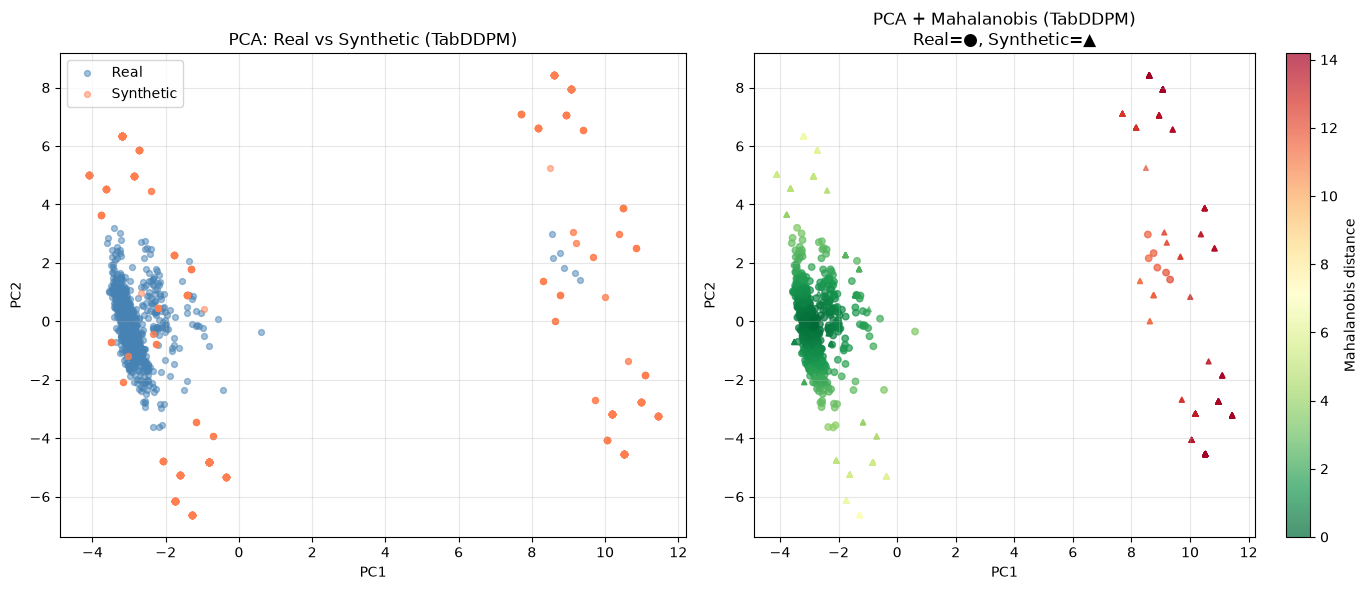

  Real mean MD: 0.9325, Synth mean MD: 8.8513, Delta: +7.9188

Processing ForestDiffusion: 1000 real vs 1000 synth


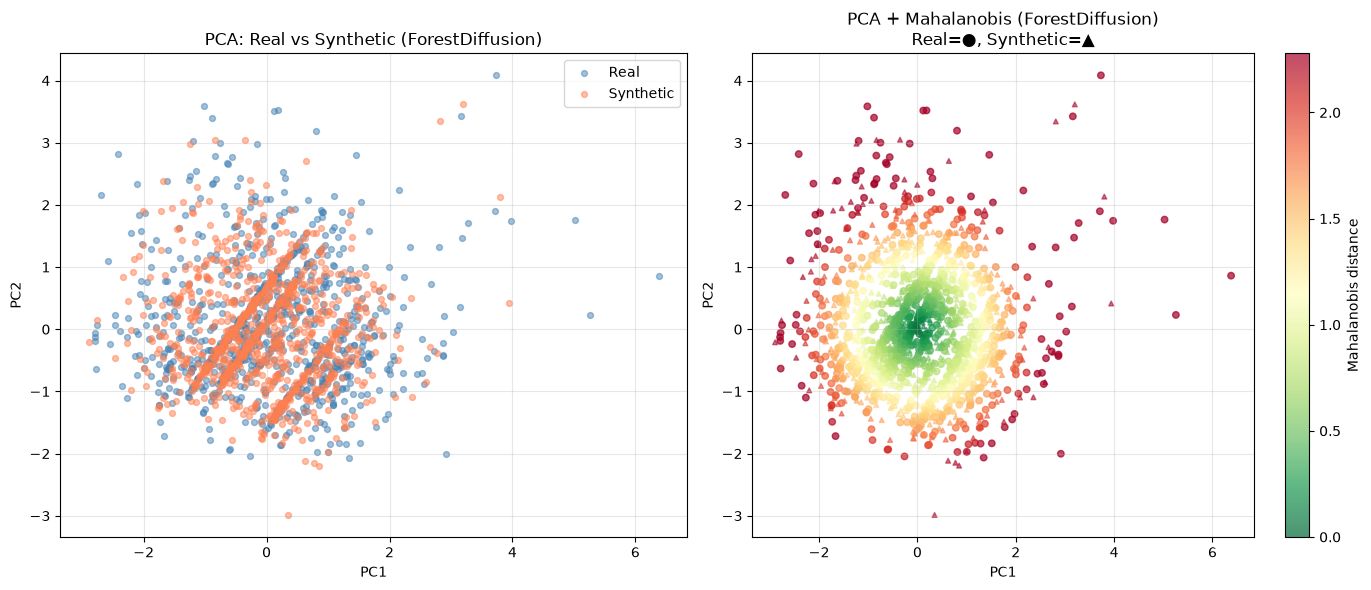

  Real mean MD: 1.2221, Synth mean MD: 1.0677, Delta: -0.1545

Adult Dataset: Summary PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
1,ForestDiffusion,1.222148,1.067685,-0.154464
0,TabDDPM,0.932470,8.851262,7.918792


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

# Direct pipeline reference
synth_source = synthetic_outputs

model_order = ["TabDDPM", "ForestDiffusion"]
real_df = real_sample.copy()
target_col = "income"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

# Scale and clean real data
X_r = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic_outputs, skipping.")
        continue

    synth_df = synth_source[model_name][feature_cols].copy()
    X_s = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    print(f"\n{'='*60}")
    print(f"Processing {model_name}: {X_r.shape[0]} real vs {X_s.shape[0]} synth")
    print(f"{'='*60}")

    # PCA on combined data
    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    # Mahalanobis in PCA space (real distribution reference)
    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    # Plot 1: PCA scatter
    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Mahalanobis distance color-coded
    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"  Real mean MD: {d_r.mean():.4f}, Synth mean MD: {d_s.mean():.4f}, Delta: {d_s.mean()-d_r.mean():+.4f}")
    
    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

# Summary table
if rows:
    summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
    print("\nAdult Dataset: Summary PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):")
    display(summary_df)
else:
    print("No valid models found.")


In [41]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Adult_Hungarian_Mahalanobis.xlsx"
):
    # Fixed model names to match your pipeline
    model_order = ["TabDDPM", "ForestDiffusion"]  # Match hungarian_results keys

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                print(f"Skipping {model_name}: missing data or results")
                continue

            synth_df = synthetic_data[model_name][num_cols].copy()
            synth_df = synth_df.fillna(synth_df.median())  # Clean NaN

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            # Flexible distance key detection
            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                print(f"No distance array found for {model_name}, skipping")
                continue

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                # Limit to first 10 numeric features for Excel practicality
                for c in num_cols[:10]:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = model_name[:31]  # Excel sheet name limit
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✓ Exported {len(matched_df)} matches for {model_name}")

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            print("\nSummary table:")
            display(summary_df)

    print(f"\n✅ Excel file created: {filename}")

# ---- Run with your actual pipeline variables ----
synth_source = synthetic_outputs  # Your generation results
real_df = real_sample.copy()     # Your Adult dataset
target_col = "income"
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

print(f"Adult Dataset: {len(real_df)} samples, {len(num_cols)} numeric features")
print(f"Target column: {target_col}")
print(f"Available models: {list(synth_source.keys())}")
print(f"Hungarian results keys: {list(hungarian_results.keys()) if 'hungarian_results' in globals() else 'Not found'}")

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,  # From your Hungarian matching cell
    num_cols=num_cols,
    filename="Adult_Hungarian_Mahalanobis.xlsx"
)


Adult Dataset: 1000 samples, 6 numeric features
Target column: income
Available models: ['TabDDPM', 'ForestDiffusion']
Hungarian results keys: ['TabDDPM', 'ForestDiffusion']
✓ Exported 1000 matches for TabDDPM
✓ Exported 1000 matches for ForestDiffusion

Summary table:


,Model,Num_Matches,Mean_Distance,Median_Distance,Std_Distance,Min_Distance,Max_Distance
1,ForestDiffusion,1000,0.683576,0.477761,0.874151,0.011377,10.677479
0,TabDDPM,1000,10.024067,9.185727,3.994602,1.828477,16.151901



✅ Excel file created: Adult_Hungarian_Mahalanobis.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [42]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

# Fixed for Adult dataset pipeline
target_col = "income"
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns if c != target_col]
model_order = ["TabDDPM", "ForestDiffusion"]

# Clean and encode real data once
real_df = real_sample.copy()
real_df[feature_cols] = real_df[feature_cols].fillna(real_df[feature_cols].median())
le = LabelEncoder()
y_real_encoded = le.fit_transform(clean_income_labels(real_df[target_col]))  # Use clean labels

results = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not in synthetic_outputs")
        continue
    
    print(f"\n{'='*50}")
    print(f"MIA for {model_name}")
    print(f"{'='*50}")
    
    synth_df = synthetic_outputs[model_name].copy()
    synth_df[feature_cols] = synth_df[feature_cols].fillna(synth_df[feature_cols].median())
    
    # Encode synthetic labels using same encoder
    y_synth_encoded = le.transform(clean_income_labels(synth_df[target_col]))

    X_train = real_df[feature_cols].to_numpy(dtype=float)
    y_train = y_real_encoded

    X_test = synth_df[feature_cols].to_numpy(dtype=float)
    y_test = y_synth_encoded

    model = LogisticRegression(max_iter=1000, random_state=42)
    metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
    
    metrics["Model"] = model_name
    results.append(metrics)
    
    print(f"  AUC: {metrics['AUC']:.4f}")
    print(f"  Advantage: {metrics['Advantage']:.4f}")
    print(f"  TPR@FPR=0.01: {metrics['TPR_at_FPR_001']:.4f}")

# Summary
if results:
    summary_df = pd.DataFrame(results).set_index("Model")
    print("\nMIA Results (LOWER AUC = BETTER privacy protection):")
    display(summary_df.sort_values("AUC"))
else:
    print("No valid models found.")



MIA for TabDDPM
  AUC: 0.6665
  Advantage: 0.4430
  TPR@FPR=0.01: 0.0000

MIA for ForestDiffusion
  AUC: 0.5193
  Advantage: 0.0690
  TPR@FPR=0.01: 0.0240

MIA Results (LOWER AUC = BETTER privacy protection):


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"<=50K": 0, ">50K": 1})
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_16788\3622507015.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, exp

,AUC,Advantage,TPR_at_FPR_001
Model,,,
ForestDiffusion,0.519265,0.069,0.024
TabDDPM,0.666547,0.443,0.000


In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

# Fixed for Adult dataset pipeline
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns 
                if c != "income"]
X_train = real_sample[feature_cols].fillna(real_sample[feature_cols].median()).to_numpy(dtype=float)

model_order = ["TabDDPM", "ForestDiffusion"]
rows = []

print("Mahalanobis MIA - Real vs Synthetic (Adult Dataset)")
print("="*70)

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not in synthetic_outputs, skipping")
        continue
    
    print(f"\n✓ Processing {model_name}...")
    X_test = synthetic_outputs[model_name][feature_cols].fillna(
        synthetic_outputs[model_name][feature_cols].median()
    ).to_numpy(dtype=float)
    
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

# Results table
if rows:
    comparison_df = pd.DataFrame(rows)[
        ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
    ].sort_values("AUC", ascending=False).reset_index(drop=True)
    
    print("\nMIA (Mahalanobis Distance) Results:")
    print("• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)")
    print("• Train/Test MD: How far synthetic samples are from real distribution")
    print("• LOWER AUC = BETTER privacy protection")
    display(comparison_df)
    
    # Privacy ranking
    print("\nPrivacy Ranking (LOWER AUC = BETTER privacy):")
    ranked = comparison_df.sort_values("AUC").reset_index(drop=True)
    for idx, row in ranked.iterrows():
        rank_emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
        print(f"{rank_emoji} {row['Model']}: AUC={row['AUC']:.3f} | Test_MD={row['Test_MD_Mean']:.3f}")
else:
    print("No valid models found.")


Mahalanobis MIA - Real vs Synthetic (Adult Dataset)

✓ Processing TabDDPM...

✓ Processing ForestDiffusion...

MIA (Mahalanobis Distance) Results:
• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)
• Train/Test MD: How far synthetic samples are from real distribution
• LOWER AUC = BETTER privacy protection


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,TabDDPM,0.995494,0.980,0.990,2.062237,10.941218
1,ForestDiffusion,0.393717,0.002,0.007,2.062237,1.674702



Privacy Ranking (LOWER AUC = BETTER privacy):
🥇 ForestDiffusion: AUC=0.394 | Test_MD=1.675
🥈 TabDDPM: AUC=0.995 | Test_MD=10.941
